## Gabi ----

🗄️ Inspecting DataStore 'fx.min' Matrices...

✅ Data Matrix Assembled Successfully!
   Total Time Steps: 2,330,879
   Date Range:       2020-01-02 06:59:00  -->  2026-04-07 21:33:00
   C:AUDUSD valid ticks: 2,330,879
   C:NZDUSD valid ticks: 2,330,877


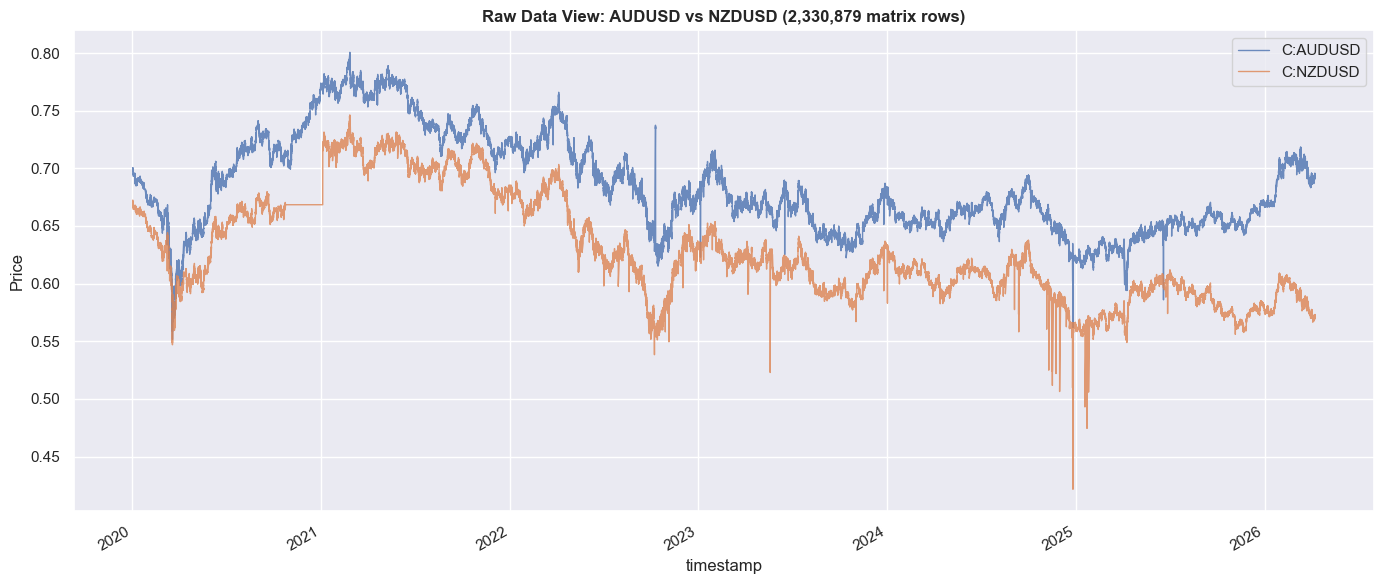

In [4]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to Bluegrey Infrastructure
sys.path.append(os.path.abspath('../..'))
from src.data.store import DataStore

print("🗄️ Inspecting DataStore 'fx.min' Matrices...")
store = DataStore(library_name="fx.min")

# 2. Use a massive date window to pull ALL available data
start_date = "2008-01-01"
end_date = pd.to_datetime("today").strftime("%Y-%m-%d")
assets = ['C:AUDUSD', 'C:NZDUSD']

# Load both assets at once (returns a dict of matrices)
matrices = store.load(assets, start_date=start_date, end_date=end_date)

if matrices and 'close' in matrices:
    # Extract the "close" matrix (Index=Time, Columns=Assets)
    close_matrix = matrices['close']
    
    if not close_matrix.empty:
        row_count = len(close_matrix)
        first_date = close_matrix.index.min()
        last_date = close_matrix.index.max()
        
        print(f"\n✅ Data Matrix Assembled Successfully!")
        print(f"   Total Time Steps: {row_count:,}")
        print(f"   Date Range:       {first_date}  -->  {last_date}")
        
        # 3. Inspect individual assets within the matrix
        for asset in assets:
            if asset in close_matrix.columns:
                # Count non-NaN values to see if an asset has missing data
                valid_ticks = close_matrix[asset].count()
                print(f"   {asset} valid ticks: {valid_ticks:,}")
        
        # 4. Plot the raw data paths
        sns.set_theme(style="darkgrid")
        plt.figure(figsize=(14, 6))
        
        # We can just call plot on the DataFrame directly now!
        close_matrix.plot(ax=plt.gca(), linewidth=1, alpha=0.8)
        
        plt.title(f"Raw Data View: AUDUSD vs NZDUSD ({row_count:,} matrix rows)", fontsize=12, fontweight='bold')
        plt.ylabel("Price")
        plt.tight_layout()
        plt.show()
    else:
        print("❌ The 'close' matrix is empty. No dates matched.")
else:
    print("❌ DATABASE EMPTY: load() returned no valid matrices.")

🗄️ Loading 1m Matrices from Librarian...


20260518 17:41:52.169119 51956565 W arcticdb | LMDB path at /Users/mateo/Bluegrey/src/data/arctic_db/ has already been opened in this process which is not supported by LMDB. You should only open a single Arctic instance over a given LMDB path. To continue safely, you should delete this Arctic instance and any others over the LMDB path in this process and then try again. Current process ID=[58743]


✅ Loaded Raw Matrix: 92,979 1-minute bars.
⏳ Resampling to 15-Minute Structural Timeframe...
✅ Resampled Matrix: 6,204 15-minute bars.
🧠 Computing M15 Dynamic Cointegration Vectors...
⚙️ Executing M15 Turnover-Aware Matrix Simulation...

📊 --- QUICK PORTFOLIO RESULTS: Kalman Filter - AUD-NZD (M15 Structural) ---
   Frictionless Return: 0.02%
   Net Strategy Return: -10.05% (EW Benchmark: 0.14%)
   Max Drawdown:        -10.19%
   Win Rate (Bars):     12.4%
   Total Fees Paid:     $10,072.22
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/Kalman_Filter_-_AUD-NZD_(M15_Structural)_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


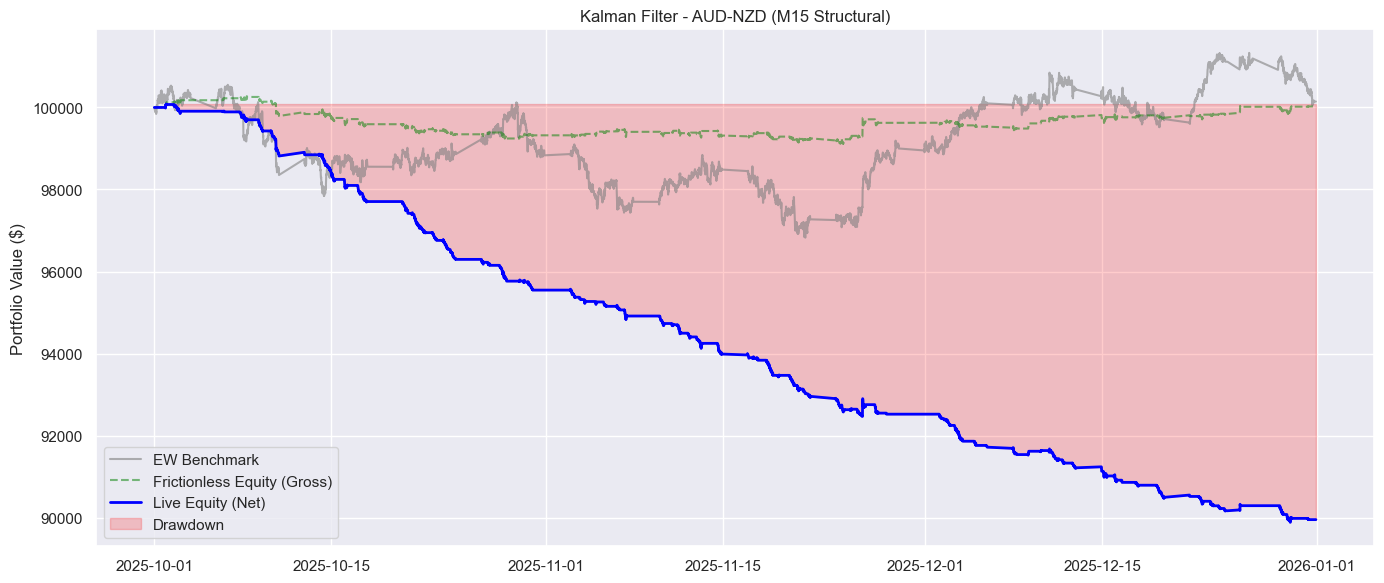

In [6]:
import sys
import os
import pandas as pd
import warnings

# 1. Connect to Bluegrey Infrastructure
sys.path.append(os.path.abspath('../..'))
from src.data.store import DataStore
from src.backtest.vector_backtester import PortfolioVectorEngine
from Gabi.kalman_pairs import KalmanPairsStrategy

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# 2. Load the Atomic 1-Minute Multi-Asset Matrix
print("🗄️ Loading 1m Matrices from Librarian...")
store = DataStore(library_name="fx.min")

leg_y = 'C:AUDUSD'
leg_x = 'C:NZDUSD'

matrices = store.load([leg_y, leg_x], start_date="2025-10-01", end_date="2026-01-01")

if matrices and 'close' in matrices and not matrices['close'].empty:
    raw_prices_matrix = matrices['close']
    print(f"✅ Loaded Raw Matrix: {raw_prices_matrix.shape[0]:,} 1-minute bars.")

    # ---------------------------------------------------------
    # 2.5 INSTITUTIONAL DOWNSAMPLING (The M15 Edge)
    # ---------------------------------------------------------
    print("⏳ Resampling to 15-Minute Structural Timeframe...")
    # '15min' or '15T' groups the index into 15-minute buckets.
    # .last() takes the final closing price of that 15-minute window.
    prices_matrix_15m = raw_prices_matrix.resample('15min').last().dropna()
    
    print(f"✅ Resampled Matrix: {prices_matrix_15m.shape[0]:,} 15-minute bars.")

    # 3. Strategy Instantiation (Adjusted for M15)
    params = {
        'leg_y': leg_y,
        'leg_x': leg_x,
        'entry_z': 2.5,      # Increased: We only want severe structural dislocations
        'exit_z': 0.5,       # Exit before mean (0.0) to avoid getting chopped by noise
        'z_lookback': 48,    # 48 bars * 15m = 12 Hours rolling window for Z-Score
        'delta': 1e-5,       # Keep adaptation rate steady
        'vt': 1e-3
    }
    
    strategy = KalmanPairsStrategy(instruments={leg_y: None, leg_x: None}, params=params)
    print("🧠 Computing M15 Dynamic Cointegration Vectors...")
    
    # Adapter for strategy expectations
    adapter_df = prices_matrix_15m.copy()
    adapter_df.columns = [f"{col}_close" for col in adapter_df.columns]
    
    signals_matrix_15m = strategy.generate_signals(adapter_df)
    
    # 4. Igniting the Portfolio Engine
    print("⚙️ Executing M15 Turnover-Aware Matrix Simulation...")
    engine = PortfolioVectorEngine(
        prices=prices_matrix_15m, 
        signals=signals_matrix_15m, 
        asset_class='FX', 
        initial_capital=100000.0,
        execution_delay=1  # 1-bar delay to prevent look-ahead
    )
    
    stats = engine.run()
    engine.tearsheet(title="Kalman Filter - AUD-NZD (M15 Structural)")

else:
    print("❌ Critical: Could not load valid matrices for backtest.")

🗄️ Loading Matrices from Librarian...


20260518 17:42:18.642552 51956565 W arcticdb | LMDB path at /Users/mateo/Bluegrey/src/data/arctic_db/ has already been opened in this process which is not supported by LMDB. You should only open a single Arctic instance over a given LMDB path. To continue safely, you should delete this Arctic instance and any others over the LMDB path in this process and then try again. Current process ID=[58743]


⏳ Resampling to 5-Minute (M5) Timeframe...
⚙️ Running Grid Search: 25 iterations...
✅ Grid Search Complete.


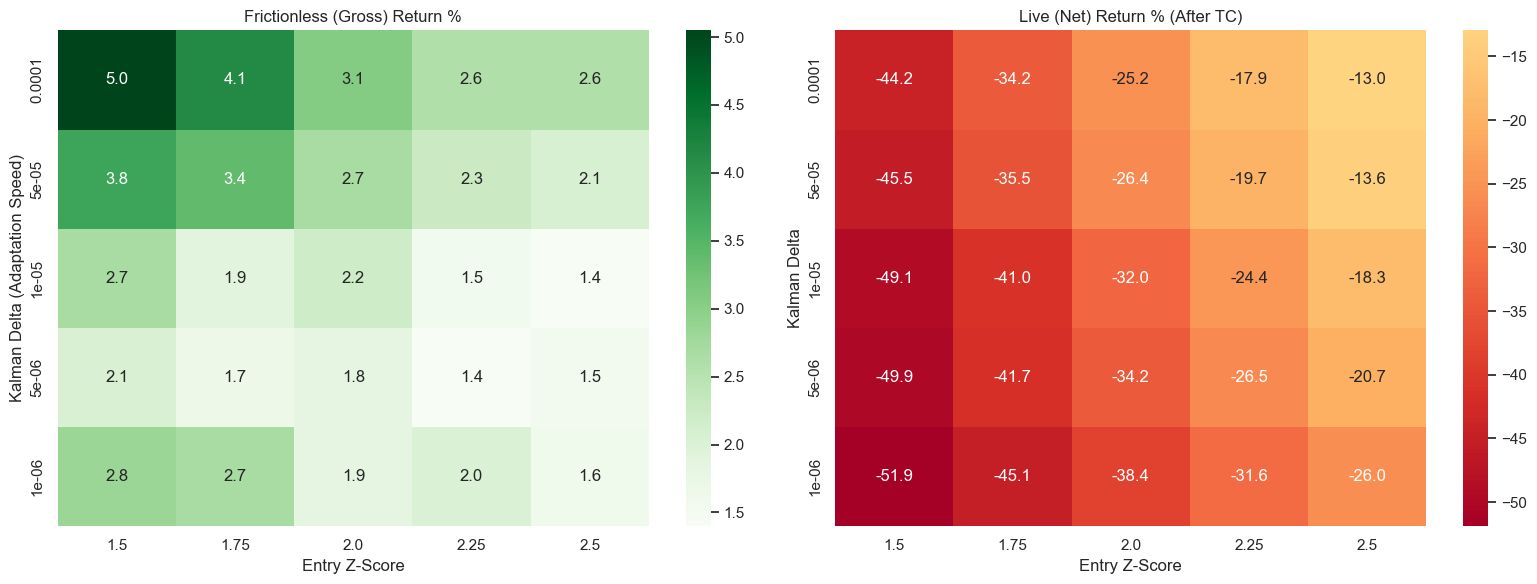

In [7]:
import sys
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# 1. Connect to Bluegrey Infrastructure
sys.path.append(os.path.abspath('../..'))
from src.data.store import DataStore
from src.backtest.vector_backtester import PortfolioVectorEngine
from Gabi.kalman_pairs import KalmanPairsStrategy

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# 2. Load the Atomic Data
print("🗄️ Loading Matrices from Librarian...")
store = DataStore(library_name="fx.min")
leg_y, leg_x = 'C:AUDUSD', 'C:NZDUSD'

matrices = store.load([leg_y, leg_x], start_date="2025-10-01", end_date="2026-01-01")
raw_prices_matrix = matrices['close']

# Try an intermediate timeframe: 5-Minute Bars (M5)
# This retains enough volatility to trigger signals, but reduces M1 hyper-churn.
print("⏳ Resampling to 5-Minute (M5) Timeframe...")
prices_matrix_m5 = raw_prices_matrix.resample('5min').last().dropna()

adapter_df = prices_matrix_m5.copy()
adapter_df.columns = [f"{col}_close" for col in adapter_df.columns]

# 3. Define the Grid Search Space
# We sweep Delta (Adaptation speed) vs Entry Z-Score
deltas = [1e-4, 5e-5, 1e-5, 5e-6, 1e-6] 
entry_zs = [1.5, 1.75, 2.0, 2.25, 2.5]
z_lookback = 100 # Approx 8 hours of M5 bars

results = np.zeros((len(deltas), len(entry_zs)))
gross_results = np.zeros((len(deltas), len(entry_zs)))

print(f"⚙️ Running Grid Search: {len(deltas) * len(entry_zs)} iterations...")

# 4. The Parameter Sweep Loop
for i, delta in enumerate(deltas):
    for j, z in enumerate(entry_zs):
        
        params = {
            'leg_y': leg_y,
            'leg_x': leg_x,
            'entry_z': z,
            'exit_z': 0.0,
            'z_lookback': z_lookback,
            'delta': delta,
            'vt': 1e-3
        }
        
        strategy = KalmanPairsStrategy(instruments={leg_y: None, leg_x: None}, params=params)
        signals = strategy.generate_signals(adapter_df)
        
        engine = PortfolioVectorEngine(
            prices=prices_matrix_m5, 
            signals=signals, 
            asset_class='FX', 
            initial_capital=100000.0,
            execution_delay=1 
        )
        
        stats = engine.run()
        
        # Calculate final Net and Gross Return %
        net_ret = (stats['net_equity'].iloc[-1] / 100000.0 - 1) * 100
        gross_ret = (stats['gross_equity'].iloc[-1] / 100000.0 - 1) * 100
        
        results[i, j] = net_ret
        gross_results[i, j] = gross_ret

print("✅ Grid Search Complete.")

# 5. Plot the Alpha Surface Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(gross_results, annot=True, fmt=".1f", xticklabels=entry_zs, yticklabels=deltas, cmap="Greens", ax=ax1)
ax1.set_title("Frictionless (Gross) Return %")
ax1.set_xlabel("Entry Z-Score")
ax1.set_ylabel("Kalman Delta (Adaptation Speed)")

sns.heatmap(results, annot=True, fmt=".1f", xticklabels=entry_zs, yticklabels=deltas, cmap="RdYlGn", center=0, ax=ax2)
ax2.set_title("Live (Net) Return % (After TC)")
ax2.set_xlabel("Entry Z-Score")
ax2.set_ylabel("Kalman Delta")

plt.tight_layout()
plt.show()

## Mateo -----

#### ––––––––– Testing with ECH –––––––––

##### ECH – `signal_threshold` = 0.002

⬇️ Downloading data for ECH from 2008-01-01 to 2020-01-01...


[*********************100%***********************]  1 of 1 completed


🧹 Cleaning dataset...
15 NaN, non-numeric and auxiliary columns have been removed.
122 rows with NaN have been cleaned.
We have 2899 rows and 399 columns (features = OHLCV + indicators + signal) in the dataset.

14 features are globally constant:
['CDL_3STARSINSOUTH', 'CDL_BREAKAWAY', 'CDL_CONCEALBABYSWALL', 'CDL_IDENTICAL3CROWS', 'CDL_KICKING', 'CDL_KICKINGBYLENGTH', 'CDL_MATHOLD', 'CDL_RISEFALL3METHODS', 'Close_X_Close', 'Close_XA_Close', 'DIV', 'SQZ_NO', 'SQZPRO_NO', 'SUB']
They will be removed as they provide no information for ML model.

✅ We now have 2899 rows and 385 columns (features = OHLCV + indicators + signal) in the dataset. 

🧠 Predicting 2019-11-21 | 2899/2899 | last: 1.37s
✅ Prediction complete.



,ECH
Date,
2018-05-21,0.1
2018-05-22,0.1
2018-05-23,0.1
2018-05-24,-0.1
2018-05-25,-0.1


,ECH
Date,
2019-11-15,0.1
2019-11-18,0.1
2019-11-19,-0.1
2019-11-20,-0.1
2019-11-21,-0.1


ECH 
-0.1    195
 0.1    186
Name: count, dtype: int64


📊 --- QUICK PORTFOLIO RESULTS: ECH MLP Walk Forward ---
   Frictionless Return: 24.83%
   Net Strategy Return: 23.95% (EW Benchmark: -35.30%)
   Max Drawdown:        -1.05%
   Win Rate (Bars):     71.1%
   Total Fees Paid:     $877.14
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_MLP_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


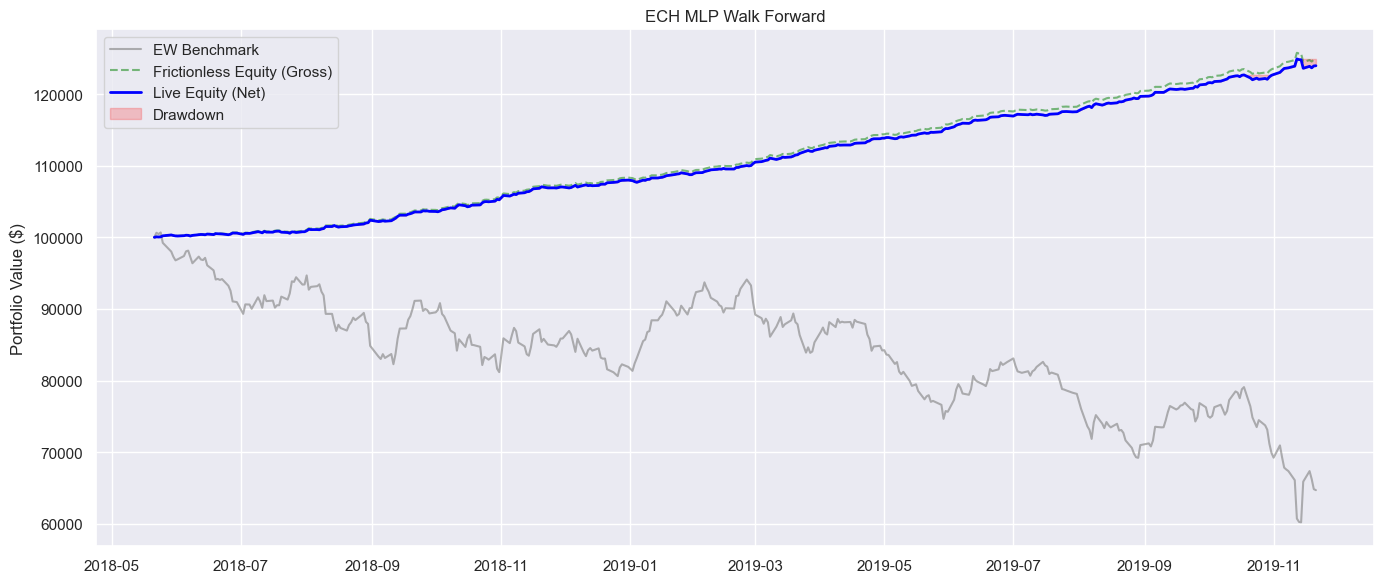

In [1]:
from ML_predictor import MLPredictorStrategy

strategy = MLPredictorStrategy(params={
    "symbol": "ECH",
    "start_date": "2008-01-01",
    "end_date": "2020-01-01",
    "signal_threshold": 0.002,
    "n_features": 8,
    "position_size": 0.10,
    "training_years": 10,
    "max_iter": 5000,
})

df = strategy.prepare_dataset()
df.head(20)


weights = strategy.generate_signals(df)
display(weights.head())
display(weights.tail())
display(weights.value_counts())


from src.backtest.vector_backtester import PortfolioVectorEngine

prices = df[["Open"]].rename(columns={"Open": "ECH"}).loc[weights.index]

engine = PortfolioVectorEngine(
    prices=prices,
    signals=weights,
    asset_class="STK",
    initial_capital=100000,
    execution_delay=0,
)

stats = engine.run()
engine.tearsheet("ECH MLP Walk Forward")


##### ECH – `training_years` = 5

⬇️ Downloading data for ECH from 2013-01-01 to 2020-01-01...


[*********************100%***********************]  1 of 1 completed


🧹 Cleaning dataset...
16 NaN, non-numeric and auxiliary columns have been removed.
114 rows with NaN have been cleaned.
We have 1648 rows and 398 columns (features = OHLCV + indicators + signal) in the dataset.

19 features are globally constant:
['CDL_3BLACKCROWS', 'CDL_3STARSINSOUTH', 'CDL_BREAKAWAY', 'CDL_CONCEALBABYSWALL', 'CDL_COUNTERATTACK', 'CDL_HIKKAKEMOD', 'CDL_IDENTICAL3CROWS', 'CDL_KICKING', 'CDL_KICKINGBYLENGTH', 'CDL_MATHOLD', 'CDL_RISEFALL3METHODS', 'CDL_STICKSANDWICH', 'Close_X_Close', 'Close_XA_Close', 'DIV', 'SQZ_NO', 'SQZPRO_NO', 'SUB', 'TANH']
They will be removed as they provide no information for ML model.

✅ We now have 1648 rows and 379 columns (features = OHLCV + indicators + signal) in the dataset. 

🧠 Predicting 2019-11-21 | 1648/1648 | last: 1.81s
✅ Prediction complete.



,ECH
Date,
2018-05-09,0.1
2018-05-10,0.1
2018-05-11,-0.1
2018-05-14,-0.1
2018-05-15,-0.1


,ECH
Date,
2019-11-15,-0.1
2019-11-18,0.1
2019-11-19,-0.1
2019-11-20,0.1
2019-11-21,0.1


ECH 
-0.1    206
 0.1    182
 0.0      1
Name: count, dtype: int64


📊 --- QUICK PORTFOLIO RESULTS: ECH MLP Walk Forward ---
   Frictionless Return: 22.86%
   Net Strategy Return: 21.93% (EW Benchmark: -34.90%)
   Max Drawdown:        -1.36%
   Win Rate (Bars):     69.2%
   Total Fees Paid:     $935.65
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_MLP_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


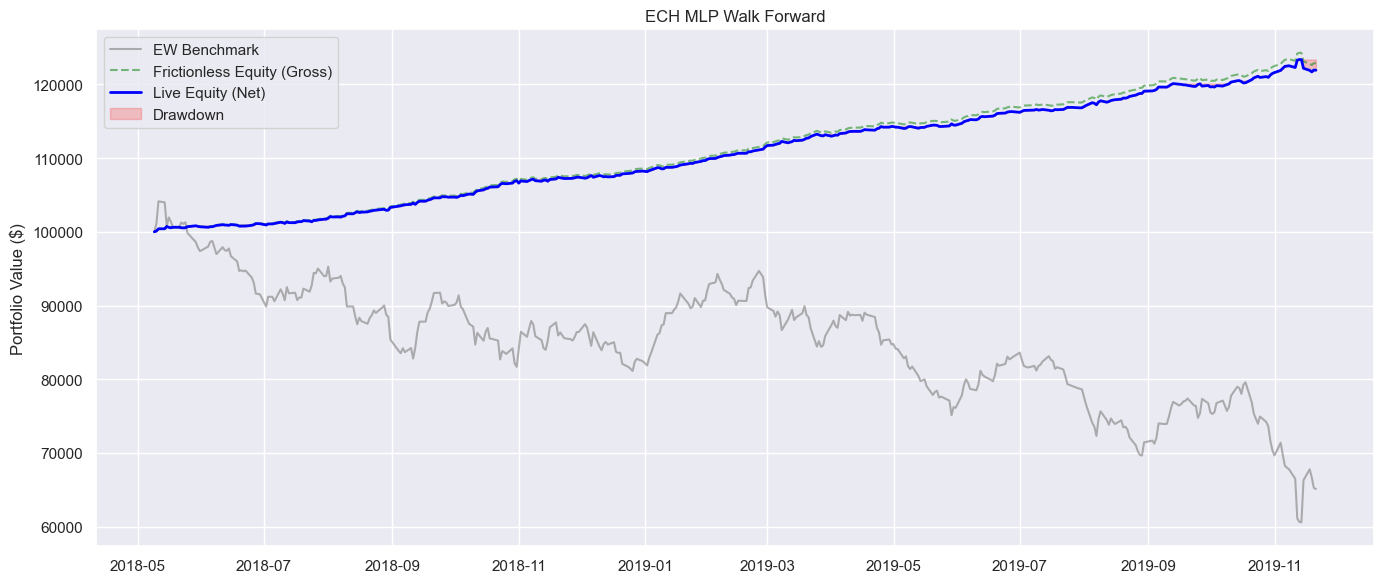

In [3]:
from ML_predictor import MLPredictorStrategy

strategy = MLPredictorStrategy(params={
    "symbol": "ECH",
    "start_date": "2013-01-01",
    "end_date": "2020-01-01",
    "signal_threshold": 0.002,
    "n_features": 8,
    "position_size": 0.10,
    "training_years": 5,
    "max_iter": 5000,
})

df = strategy.prepare_dataset()
df.head(20)


weights = strategy.generate_signals(df)
display(weights.head())
display(weights.tail())
display(weights.value_counts())


from src.backtest.vector_backtester import PortfolioVectorEngine

prices = df[["Open"]].rename(columns={"Open": "ECH"}).loc[weights.index]

engine = PortfolioVectorEngine(
    prices=prices,
    signals=weights,
    asset_class="STK",
    initial_capital=100000,
    execution_delay=0,
)

stats = engine.run()
engine.tearsheet("ECH MLP Walk Forward")


##### ECH – new download and predict functions – `training_years` = 5

I want to edit the strategy file `ML_predictor.py` so that:
- it receives a time range for predictions to be made – ie. "2018-01-01" to "2019-01-01"
- it goes and downloads the necessary history for that range – ie. 'Y' years before start_date
- it runs predictor only through prediction time range (instead of also running for all the downloaded dataset as it does at the moment)

⬇️ Downloading data for ECH from 2013-05-01 00:00:00 to 2020-01-01...


[*********************100%***********************]  1 of 1 completed


🧹 Cleaning dataset...
17 NaN, non-numeric and auxiliary columns have been removed.
103 rows with NaN have been cleaned.
We have 1577 rows and 397 columns (features = OHLCV + indicators + signal) in the dataset.

19 features are globally constant:
['CDL_3BLACKCROWS', 'CDL_3STARSINSOUTH', 'CDL_BREAKAWAY', 'CDL_CONCEALBABYSWALL', 'CDL_COUNTERATTACK', 'CDL_HIKKAKEMOD', 'CDL_IDENTICAL3CROWS', 'CDL_KICKING', 'CDL_KICKINGBYLENGTH', 'CDL_MATHOLD', 'CDL_RISEFALL3METHODS', 'CDL_STICKSANDWICH', 'Close_X_Close', 'Close_XA_Close', 'DIV', 'SQZ_NO', 'SQZPRO_NO', 'SUB', 'TANH']
They will be removed as they provide no information for ML model.

✅ We now have 1577 rows and 378 columns (features = OHLCV + indicators + signal) in the dataset. 

🧠 Predicting 2019-11-21 |  395/395 |  last: 1.86s |  elapsed: 598.69s
✅ Prediction complete. Took 600.2s



,ECH
Date,
2018-08-20,0.1
2018-08-21,0.1
2018-08-22,0.1
2018-08-23,-0.1
2018-08-24,0.1


,ECH
Date,
2019-11-15,-0.1
2019-11-18,0.1
2019-11-19,-0.1
2019-11-20,0.1
2019-11-21,0.1


ECH 
-0.1    170
 0.1    147
 0.0      1
Name: count, dtype: int64


📊 --- QUICK PORTFOLIO RESULTS: ECH MLP Walk Forward ---
   Frictionless Return: 19.71%
   Net Strategy Return: 18.95% (EW Benchmark: -25.62%)
   Max Drawdown:        -1.36%
   Win Rate (Bars):     72.3%
   Total Fees Paid:     $764.83
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_MLP_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


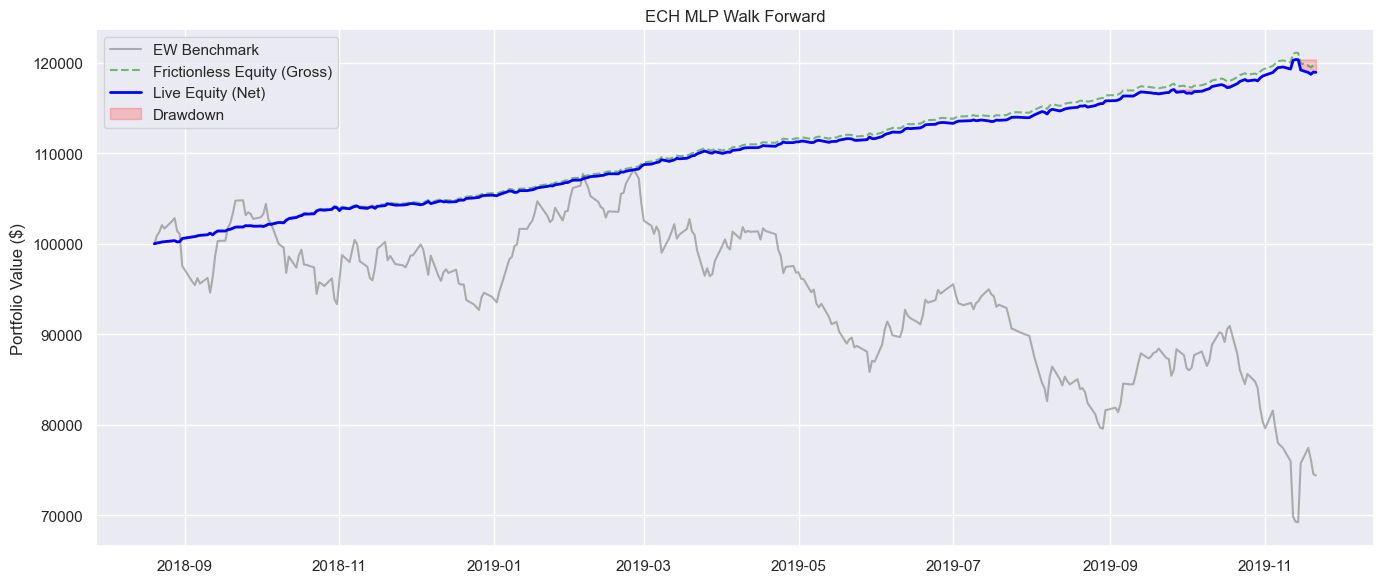

In [ ]:
from ML_predictor import MLPredictorStrategy

strategy = MLPredictorStrategy(params={
    "symbol": "ECH",
    "start_date": "2018-05-01",
    "end_date": "2020-01-01",
    "signal_threshold": 0.002,
    "n_features": 8,
    "position_size": 0.10,
    "training_years": 5,
    "max_iter": 5000,
    "verbose": True
})

df = strategy.prepare_dataset()
df.head(20)


weights = strategy.generate_signals(df)
display(weights.head())
display(weights.tail())
display(weights.value_counts())


from src.backtest.vector_backtester import PortfolioVectorEngine

prices = df[["Open"]].rename(columns={"Open": "ECH"}).loc[weights.index]

engine = PortfolioVectorEngine(
    prices=prices,
    signals=weights,
    asset_class="STK",
    initial_capital=100000,
    execution_delay=0,
)

stats = engine.run()
engine.tearsheet("ECH MLP Walk Forward")


##### ECH – new download and predict functions – `position_size` = 0.3 – `training_years` = 5

⬇️ Downloading data for ECH from 2013-05-01 00:00:00 to 2021-01-01...


[*********************100%***********************]  1 of 1 completed


🧹 Cleaning dataset...
15 NaN, non-numeric and auxiliary columns have been removed.
122 rows with NaN have been cleaned.
We have 1811 rows and 399 columns (features = OHLCV + indicators + signal) in the dataset.

17 features are globally constant:
['CDL_3BLACKCROWS', 'CDL_3STARSINSOUTH', 'CDL_BREAKAWAY', 'CDL_CONCEALBABYSWALL', 'CDL_COUNTERATTACK', 'CDL_IDENTICAL3CROWS', 'CDL_KICKING', 'CDL_KICKINGBYLENGTH', 'CDL_MATHOLD', 'CDL_RISEFALL3METHODS', 'CDL_STICKSANDWICH', 'Close_X_Close', 'Close_XA_Close', 'DIV', 'SQZ_NO', 'SQZPRO_NO', 'SUB']
They will be removed as they provide no information for ML model.

✅ We now have 1811 rows and 382 columns (features = OHLCV + indicators + signal) in the dataset. 

🧠 Predicting 2020-11-23 |  397/397 |  last: 0.90s |  elapsed: 13.0m 7.9ss
✅ Prediction complete. Took 13.0m 9.3s



,ECH
Date,
2019-05-01,-0.3
2019-05-02,-0.3
2019-05-03,0.3
2019-05-06,0.3
2019-05-07,-0.3


,ECH
Date,
2020-11-17,0.3
2020-11-18,0.3
2020-11-19,0.3
2020-11-20,-0.3
2020-11-23,-0.3


ECH 
-0.3    218
 0.3    179
Name: count, dtype: int64


📊 --- QUICK PORTFOLIO RESULTS: ECH MLP Walk Forward ---
   Frictionless Return: 135.20%
   Net Strategy Return: 130.95% (EW Benchmark: -32.54%)
   Max Drawdown:        -4.87%
   Win Rate (Bars):     68.8%
   Total Fees Paid:     $4,246.89
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_MLP_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


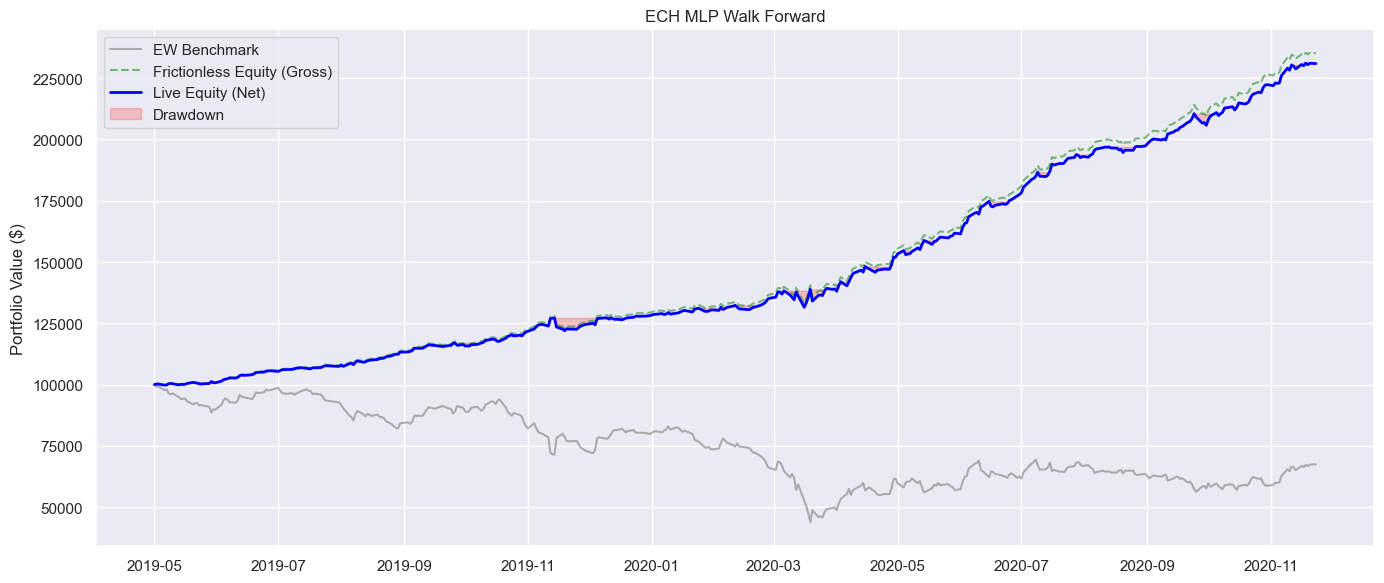

In [1]:
from ML_predictor import MLPredictorStrategy

strategy = MLPredictorStrategy(params={
    "symbol": "ECH",
    "start_date": "2019-05-01",
    "end_date": "2021-01-01",
    "signal_threshold": 0.002,
    "n_features": 8,
    "position_size": 0.30,
    "training_years": 5,
    "max_iter": 5000,
    "verbose": True
})

df = strategy.prepare_dataset()
df.head(20)


weights = strategy.generate_signals(df)
display(weights.head())
display(weights.tail())
display(weights.value_counts())


from src.backtest.vector_backtester import PortfolioVectorEngine

prices = df[["Open"]].rename(columns={"Open": "ECH"}).loc[weights.index]

engine = PortfolioVectorEngine(
    prices=prices,
    signals=weights,
    asset_class="STK",
    initial_capital=100000,
    execution_delay=0,
)

stats = engine.run()
engine.tearsheet("ECH MLP Walk Forward")


##### ECH – new download and predict functions – `position_size` = 0.3 – `training_years` = 5 – until today

⬇️ Downloading data for ECH from 2010-01-01 00:00:00 to 2026-01-11...


[*********************100%***********************]  1 of 1 completed


🧹 Cleaning dataset...
15 NaN, non-numeric and auxiliary columns have been removed.
122 rows with NaN have been cleaned.
We have 3908 rows and 399 columns (features = OHLCV + indicators + signal) in the dataset.

13 features are globally constant:
['CDL_3STARSINSOUTH', 'CDL_CONCEALBABYSWALL', 'CDL_IDENTICAL3CROWS', 'CDL_KICKING', 'CDL_KICKINGBYLENGTH', 'CDL_MATHOLD', 'CDL_RISEFALL3METHODS', 'Close_X_Close', 'Close_XA_Close', 'DIV', 'SQZ_NO', 'SQZPRO_NO', 'SUB']
They will be removed as they provide no information for ML model.

✅ We now have 3908 rows and 386 columns (features = OHLCV + indicators + signal) in the dataset. 

🧠 Predicting 2025-12-02 |  2494/2494 |  last: 1.04s |  elapsed: 44.0m 48.3s
✅ Prediction complete. Took 44.0m 49.0s



,ECH
Date,
2016-01-04,-0.1
2016-01-05,-0.1
2016-01-06,0.1
2016-01-07,-0.1
2016-01-08,-0.1


,ECH
Date,
2025-11-25,-0.1
2025-11-26,-0.1
2025-11-28,-0.1
2025-12-01,-0.1
2025-12-02,-0.1


ECH 
-0.1    1372
 0.1    1121
 0.0       1
Name: count, dtype: int64


📊 --- QUICK PORTFOLIO RESULTS: ECH MLP Walk Forward ---
   Frictionless Return: 312.52%
   Net Strategy Return: 301.14% (EW Benchmark: 64.84%)
   Max Drawdown:        -2.99%
   Win Rate (Bars):     65.8%
   Total Fees Paid:     $11,374.19
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_MLP_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


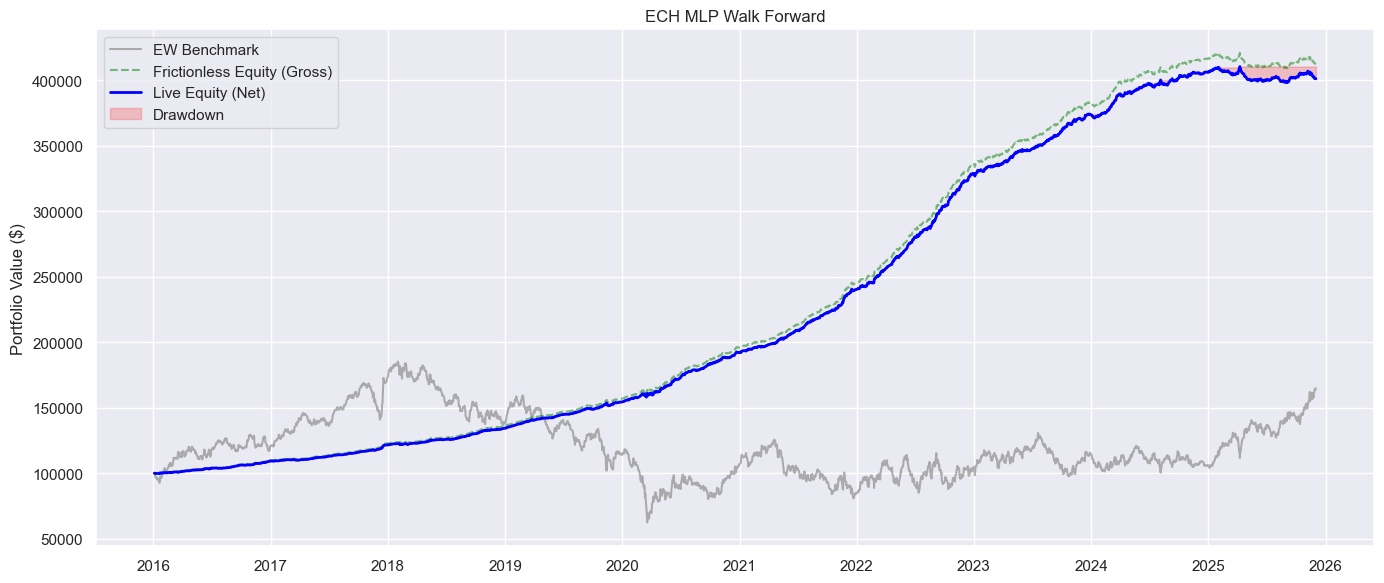

In [2]:
from ML_predictor import MLPredictorStrategy

strategy = MLPredictorStrategy(params={
    "symbol": "ECH",
    "start_date": "2016-01-01",
    "end_date": "2026-01-11",
    "signal_threshold": 0.002,
    "n_features": 8,
    "position_size": 0.10,
    "training_years": 5,
    "max_iter": 5000,
    "verbose": True
})

df = strategy.prepare_dataset()
df.head(20)


weights = strategy.generate_signals(df)
display(weights.head())
display(weights.tail())
display(weights.value_counts())


from src.backtest.vector_backtester import PortfolioVectorEngine

prices = df[["Open"]].rename(columns={"Open": "ECH"}).loc[weights.index]

engine = PortfolioVectorEngine(
    prices=prices,
    signals=weights,
    asset_class="STK",
    initial_capital=100000,
    execution_delay=0,
)

stats = engine.run()
engine.tearsheet("ECH MLP Walk Forward")


#### ––––––––––– Optimisation –––––––––––

##### ECH – `signal_threshold` VS. `n_features`

🧠 Predicting 2023-12-29 |  250/250 |  last: 0.45s |  elapsed: 1m 39.3s
✅ Prediction complete. Took 1m 39.7s

🧠 Predicting 2023-12-29 |  250/250 |  last: 0.49s |  elapsed: 2m 21.6s
✅ Prediction complete. Took 2m 22.1s

🧠 Predicting 2023-12-29 |  250/250 |  last: 0.42s |  elapsed: 1m 31.0s
✅ Prediction complete. Took 1m 31.4s

🧠 Predicting 2023-12-29 |  250/250 |  last: 0.36s |  elapsed: 1m 16.4s
✅ Prediction complete. Took 1m 16.8s

🧠 Predicting 2023-12-29 |  250/250 |  last: 0.39s |  elapsed: 1m 32.2s
✅ Prediction complete. Took 1m 32.5s

🧠 Predicting 2023-12-29 |  250/250 |  last: 0.27s |  elapsed: 1m 26.2s
✅ Prediction complete. Took 1m 26.6s

🧠 Predicting 2023-12-29 |  250/250 |  last: 0.46s |  elapsed: 2m 0.1ss
✅ Prediction complete. Took 2m 0.6s

🧠 Predicting 2023-12-29 |  250/250 |  last: 0.57s |  elapsed: 2m 20.8s
✅ Prediction complete. Took 2m 21.3s

🧠 Predicting 2023-12-29 |  250/250 |  last: 0.57s |  elapsed: 5m 50.1s
✅ Prediction complete. Took 5m 50.9s

🧠 Predicting 2023-12

,n_features,signal_threshold,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,3,0.000,22.697839,23.389019,122697.839005,123389.018814
1,3,0.001,22.994574,23.684601,122994.574365,123684.601198
2,3,0.002,23.907841,24.620537,123907.841229,124620.536564
3,3,0.003,22.847061,23.557427,122847.061344,123557.427301
4,3,0.005,21.421056,22.116988,121421.055865,122116.988218
...,...,...,...,...,...,...
76,11,0.005,13.638087,14.274879,113638.087486,114274.878905
77,11,0.007,2.090795,2.199758,102090.795211,102199.758065
78,11,0.010,0.057499,0.082622,100057.498711,100082.622464
79,11,0.015,0.311429,0.317044,100311.428835,100317.043775


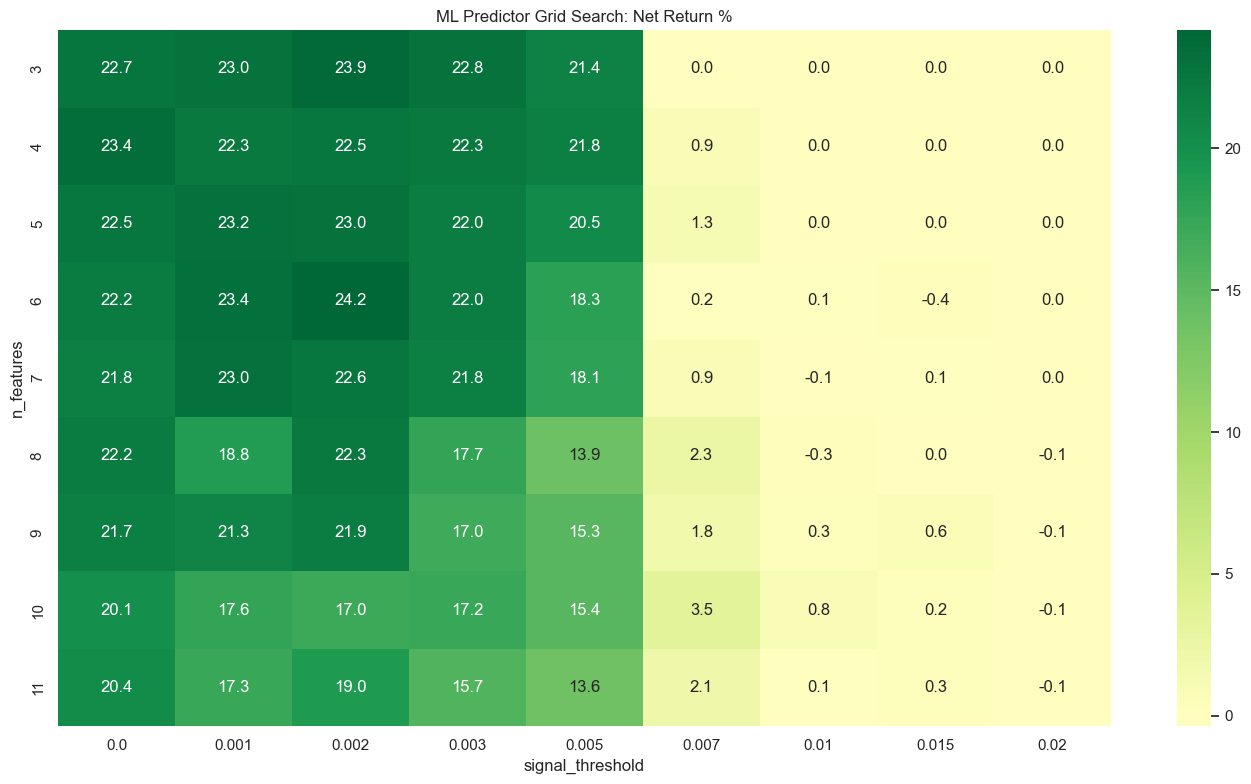

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ML_predictor import MLPredictorStrategy
from src.backtest.vector_backtester import PortfolioVectorEngine

# signal_thresholds = [0, 0.001, 0.003, 0.005, 0.007, 0.010, 0.0125, 0.0150, 0.175, 0.020]
signal_thresholds = [0, 0.001, 0.002, 0.003, 0.005, 0.007, 0.010, 0.0150, 0.020]
# signal_thresholds = [0, 0.001]

# n_features_values = [5, 6, 7, 8, 9, 10, 11, 12, 13]
n_features_values = [3, 4, 5, 6, 7, 8, 9, 10, 11]
# n_features_values = [7, 8]

grid_records = []

for n_features in n_features_values:
    for signal_threshold in signal_thresholds:
        params = {
            "symbol": "ECH",
            "start_date": "2023-01-01",
            "end_date": "2024-01-01",
            "signal_threshold": signal_threshold,
            "n_features": n_features,
            "position_size": 0.10,
            "training_years": 10,
            "max_iter": 5000,
            "verbose": False
        }

        strategy = MLPredictorStrategy(params=params)
        dataset = strategy.prepare_dataset()
        weights = strategy.generate_signals(dataset)

        if weights.empty:
            continue

        prices_run = dataset[["Open"]].rename(columns={"Open": "ECH"}).loc[weights.index]

        engine_run = PortfolioVectorEngine(
            prices=prices_run,
            signals=weights,
            asset_class="STK",
            initial_capital=100000,
            execution_delay=0,
        )

        stats_run = engine_run.run()
        net_return_pct = (stats_run["net_equity"].iloc[-1] / 100000 - 1) * 100
        gross_return_pct = (stats_run["gross_equity"].iloc[-1] / 100000 - 1) * 100

        grid_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "net_return_pct": net_return_pct,
            "gross_return_pct": gross_return_pct,
            "final_net_equity": stats_run["net_equity"].iloc[-1],
            "final_gross_equity": stats_run["gross_equity"].iloc[-1],
        })

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="signal_threshold", values="net_return_pct")

display(grid_df.sort_values(["n_features", "signal_threshold"]).reset_index(drop=True))

plt.figure(figsize=(14, 8))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title("ML Predictor Grid Search: Net Return %")
plt.xlabel("signal_threshold")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

Best combination: `n_features` = 6 , `signal_threshold` = 0.002

#### SPY

##### The time range "2020-01-01" – "2021-01-01" gives an error for SPY. This only happens for this time frame but not others.

In [ ]:
import numpy as np
import importlib
import ML_predictor
importlib.reload(ML_predictor)
from ML_predictor import MLPredictorStrategy


strategy_SPY = MLPredictorStrategy(params={
    "symbol": "SPY",
    "start_date": "2020-01-01",
    "end_date": "2021-01-01",
    "signal_threshold": 0.001,
    "n_features": 8,
    "position_size": 1.00,
    "training_years": 5,
    "max_iter": 5000,
    "verbose": True
})

df_SPY = strategy_SPY.prepare_dataset()
print("🫧 Clean dataset:")
display(df_SPY)

df = df_SPY.copy()


weights = strategy_SPY.generate_signals(df)
print("🏋️‍♂️ Weights summary:")
display(weights.value_counts())
display(weights)


from src.backtest.vector_backtester import PortfolioVectorEngine

prices = df[["Open"]].rename(columns={"Open": "SPY"}).loc[weights.index]

engine = PortfolioVectorEngine(
    prices=prices,
    signals=weights,
    asset_class="STK",
    initial_capital=100000,
    execution_delay=0,
)

stats = engine.run()
engine.tearsheet("SPY MLP Walk Forward")


⬇️ Downloading data for SPY from 2014-01-01 to 2021-01-01...


[*********************100%***********************]  1 of 1 completed

🧪 Assigning singal to historic dataset...
🧪 Computing technical indicators...


🧹 Cleaning dataset...
☑️ 51 NaN, non-numeric and auxiliary columns have been removed:
['Open_t+1', 'Open_t+2', 'ACOS', 'ASIN', 'CPR_WIDTH_CLASS', 'CPR_POSITION', 'HILOl_13_21', 'HILOs_13_21', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'SUPERTl_7_3.0', 'SUPERTs_7_3.0', 'TRIXs_30_9', 'VFI_130', 'TOS_STDEVALL_180_LR', 'TOS_STDEVALL_180_L_1', 'TOS_STDEVALL_180_U_1', 'TOS_STDEVALL_180_L_2', 'TOS_STDEVALL_180_U_2', 'TOS_STDEVALL_180_L_3', 'TOS_STDEVALL_180_U_3', 'TOS_STDEVALL_252_LR', 'TOS_STDEVALL_252_L_1', 'TOS_STDEVALL_252_U_1', 'TOS_STDEVALL_252_L_2', 'TOS_STDEVALL_252_U_2', 'TOS_STDEVALL_252_L_3', 'TOS_STDEVALL_252_U_3', 'TOS_STDEVALL_500_LR', 'TOS_STDEVALL_500_L_1', 'TOS_STDEVALL_500_U_1', 'TOS_STDEVALL_500_L_2', 'TOS_STDEVALL_500_U_2', 'TOS_STDEVALL_500_L_3', 'TOS_STDEVALL_500_U_3', 'TOS_STDEVALL_1000_LR', 'TOS_STDEVALL_1000_L_1', 'TOS_STDEVALL_1000_U_1', 'TOS_STDEVALL_1000_L_2', 'TOS_STDEVALL_1000_U_2', 'TOS_STDEVALL_1000_L_3', 'TOS_STDEVALL_1000_U_3', 

SPY,Open,High,Low,Close,Volume,Signal,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,...,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3,TOS_STDEVALL_90_LR,TOS_STDEVALL_90_L_1,TOS_STDEVALL_90_U_1,TOS_STDEVALL_90_L_2,TOS_STDEVALL_90_U_2,TOS_STDEVALL_90_L_3,TOS_STDEVALL_90_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2014-05-12,154.033224,154.914348,153.380539,154.840912,86940000,-1.0,153.262009,154.689734,151.834283,1.427726,...,156.495223,148.774356,158.039396,153.690807,150.781349,156.600265,147.871892,159.509722,144.962434,162.419180
2014-05-13,155.044902,155.354931,154.824631,154.979645,66454000,-1.0,153.724320,155.092217,152.356422,1.367897,...,156.966502,148.908907,158.578021,153.863526,150.916645,156.810407,147.969763,159.757288,145.022882,162.704170
2014-05-14,154.840962,154.914398,154.025108,154.245392,72367000,-1.0,154.043594,155.383934,152.703254,1.340340,...,157.300219,149.146681,158.930926,153.998920,151.028648,156.969192,148.058377,159.939464,145.088105,162.909736
2014-05-15,153.935344,153.967986,152.140468,152.891052,154956000,0.0,153.977769,155.369082,152.586457,1.391312,...,157.403924,149.374873,159.009734,154.061378,151.088537,157.034219,148.115696,160.007060,145.142855,162.979901
2014-05-16,152.980773,153.486611,152.336254,153.421341,97458000,1.0,153.981574,155.356823,152.606326,1.375249,...,157.595393,149.625110,159.189449,154.163741,151.177596,157.149886,148.191451,160.136032,145.205306,163.122177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-24,342.658146,343.542545,342.071682,343.514618,26457900,1.0,343.029932,347.167714,338.892149,4.137783,...,354.812604,330.776105,359.619903,339.764934,326.894086,352.635783,314.023238,365.506631,301.152390,378.377479
2020-12-28,346.065406,346.856705,345.441696,346.465729,39000400,-1.0,343.556234,347.640970,339.471497,4.084736,...,354.693822,331.755277,359.281531,340.538880,327.492777,353.584983,314.446674,366.631085,301.400572,379.677188
2020-12-29,347.992449,348.169329,345.218256,345.804749,53680500,-1.0,344.049010,348.058169,340.039852,4.009159,...,355.061807,332.242915,359.625585,341.279757,328.075091,354.484424,314.870425,367.689090,301.665758,380.893757


🧠 Predicting 2020-01-14 |  9/253 |  last: 1.45s |  elapsed: 11.4s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


🧠 Predicting 2020-01-29 |  19/253 |  last: 1.59s |  elapsed: 21.9s

##### Test to find out what's wrong with SPY

In [12]:
import numpy as np
import importlib
import ML_predictor
importlib.reload(ML_predictor)
from ML_predictor import MLPredictorStrategy


strategy_SPY = MLPredictorStrategy(params={
    "symbol": "SPY",
    "start_date": "2020-01-01",
    "end_date": "2020-02-01",
    "signal_threshold": 0.001,
    "n_features": 8,
    "position_size": 0.10,
    "training_years": 5,
    "max_iter": 5000,
    "verbose": True
})

df_SPY = strategy_SPY.prepare_dataset()
# print("🫧 Clean dataset:")
# display(df_SPY)

df = df_SPY.copy()

# print("Any cells with NaNs?:")
# display(df.loc[df.isna().any(axis=1), df.isna().any(axis=0)])

# print("Any cells with non-finite numbers?:")
# display(df.loc[~np.isfinite(df).all(axis=1), ~np.isfinite(df).all(axis=0)])

# print("🧐 Test target split...")
# test_split = strategy_SPY.feature_target_split_dataset(df_SPY)
# display(test_split[0])
# display(test_split[1])

# print("🧐 Test pipleine...")
# test_pipeline = strategy_SPY.build_pipeline()
# display(test_pipeline)

# print("🧐 Test model training...")
# test_train = strategy_SPY.train_and_fit(test_split[0], test_split[1])
# display(test_train)

print("🧐 Test predict...")
# test_predict = strategy_SPY.predict(df)
test_predict = strategy_SPY.predict_debug(df)
display(test_predict)

# weights = strategy_SPY.generate_signals(df)
# print("🏋️‍♂️ Weights summary:")
# display(weights.value_counts())


# from src.backtest.vector_backtester import PortfolioVectorEngine

# prices = df[["Open"]].rename(columns={"Open": "SPY"}).loc[weights.index]

# engine = PortfolioVectorEngine(
#     prices=prices,
#     signals=weights,
#     asset_class="STK",
#     initial_capital=100000,
#     execution_delay=0,
# )

# stats = engine.run()
# engine.tearsheet("SPY MLP Walk Forward")


⬇️ Downloading data for SPY from 2014-01-01 to 2020-02-01...


[*********************100%***********************]  1 of 1 completed

🧪 Assigning singal to historic dataset...
🧪 Computing technical indicators...


🧹 Cleaning dataset...
☑️ 59 NaN, non-numeric and auxiliary columns have been removed:
['Open_t+1', 'Open_t+2', 'ACOS', 'ASIN', 'CPR_WIDTH_CLASS', 'CPR_POSITION', 'HILOl_13_21', 'HILOs_13_21', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'SUPERTl_7_3.0', 'SUPERTs_7_3.0', 'TRIX_30_9', 'TRIXs_30_9', 'VFI_130', 'TOS_STDEVALL_90_LR', 'TOS_STDEVALL_90_L_1', 'TOS_STDEVALL_90_U_1', 'TOS_STDEVALL_90_L_2', 'TOS_STDEVALL_90_U_2', 'TOS_STDEVALL_90_L_3', 'TOS_STDEVALL_90_U_3', 'TOS_STDEVALL_180_LR', 'TOS_STDEVALL_180_L_1', 'TOS_STDEVALL_180_U_1', 'TOS_STDEVALL_180_L_2', 'TOS_STDEVALL_180_U_2', 'TOS_STDEVALL_180_L_3', 'TOS_STDEVALL_180_U_3', 'TOS_STDEVALL_252_LR', 'TOS_STDEVALL_252_L_1', 'TOS_STDEVALL_252_U_1', 'TOS_STDEVALL_252_L_2', 'TOS_STDEVALL_252_U_2', 'TOS_STDEVALL_252_L_3', 'TOS_STDEVALL_252_U_3', 'TOS_STDEVALL_500_LR', 'TOS_STDEVALL_500_L_1', 'TOS_STDEVALL_500_U_1', 'TOS_STDEVALL_500_L_2', 'TOS_STDEVALL_500_U_2', 'TOS_STDEVALL_500_L_3', 'TOS_STDEVALL_500_U_3', '

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,295.672691,296.906418,294.749676,296.888123,59151200,294.730213,296.567952,292.892474,1.837739,286.118892,...,271.686789,293.738382,288.104708,295.219512,290.656139,299.782886,286.092766,304.346259,281.529393,308.909632


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-03 |  2/21 |  last: 0.00s |  elapsed: 1.0s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,293.497741,295.764143,293.442911,294.640076,77709700,294.707056,296.65196,292.762152,1.944904,286.61285,...,271.996014,294.393287,288.104708,295.742693,291.114583,300.370804,286.486472,304.998914,281.858362,309.627025


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-06 |  3/21 |  last: 0.00s |  elapsed: 2.0s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-06,292.885485,295.846435,292.766677,295.764191,55653900,294.633355,296.653916,292.612795,2.020561,286.974266,...,272.409744,294.740566,288.104708,296.267394,291.597224,300.937563,286.927055,305.607733,282.256885,310.277903


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-07 |  4/21 |  last: 0.00s |  elapsed: 3.1s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-07,295.197588,295.672817,294.484772,294.932587,40496400,294.863676,296.834828,292.892525,1.971151,287.406332,...,272.955411,294.740566,288.104708,296.57142,291.958973,301.183868,287.346525,305.796315,282.734077,310.408763


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-08 |  5/21 |  last: 0.00s |  elapsed: 4.0s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-08,295.124415,297.719796,294.877681,296.504364,68296000,295.397378,297.426593,293.368162,2.029216,287.724157,...,272.955411,295.147255,288.511397,297.034294,292.418982,301.649606,287.803669,306.264919,283.188357,310.880231


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-09 |  6/21 |  last: 0.00s |  elapsed: 5.1s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-09,298.067045,298.587957,297.482157,298.514832,48473300,295.800093,297.832934,293.767252,2.032841,288.422269,...,272.955411,295.581336,288.945478,297.809866,293.033528,302.586204,288.257189,307.362543,283.480851,312.138881


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-10 |  7/21 |  last: 0.00s |  elapsed: 6.6s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-10,299.09978,299.255122,297.1898,297.655853,53029300,296.483669,298.518675,294.448663,2.035006,288.938231,...,272.955411,295.914918,290.729512,298.432151,293.560788,303.303514,288.689425,308.174876,283.818062,313.046239


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-13 |  8/21 |  last: 0.00s |  elapsed: 7.6s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-13,298.27725,299.712001,297.847731,299.702881,47086800,297.34269,299.379105,295.306274,2.036416,289.704805,...,272.955411,296.143358,291.076173,299.321417,294.24502,304.397815,289.168623,309.474212,284.092226,314.550609


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-14 |  9/21 |  last: 0.00s |  elapsed: 10.3s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-14,299.264208,300.315151,298.688467,299.245941,62832800,298.219982,300.229082,296.210882,2.0091,290.347615,...,272.955411,296.540914,292.391746,299.999152,294.818871,305.179433,289.63859,310.359714,284.458309,315.539995


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-15 |  10/21 |  last: 0.00s |  elapsed: 11.6s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-15,299.154626,300.68077,299.072381,299.922272,72056600,298.924888,300.907274,296.942502,1.982386,290.978049,...,272.955411,296.723724,292.574555,300.51429,295.353518,305.675063,290.192745,310.835836,285.031972,315.996608


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-16 |  11/21 |  last: 0.00s |  elapsed: 13.8s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-16,301.302134,302.417053,301.073667,302.417053,54050300,299.679743,301.696288,297.663197,2.016546,291.440926,...,272.955411,297.591865,293.442697,301.112693,296.021276,306.20411,290.929858,311.295527,285.838441,316.386945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-17 |  12/21 |  last: 0.00s |  elapsed: 14.7s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-17,303.12984,303.568479,302.353047,303.358307,95846000,300.69168,302.654818,298.728542,1.963138,291.973708,...,272.955411,299.026625,294.304893,301.81139,296.700882,306.921899,291.590373,312.032408,286.479865,317.142916


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-21 |  13/21 |  last: 0.00s |  elapsed: 15.5s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-21,302.398771,303.568521,302.325674,302.764313,77742400,301.451406,303.366525,299.536288,1.915119,292.569916,...,272.955411,299.223101,294.636813,302.338881,297.296963,307.380799,292.255045,312.422718,287.213126,317.464636


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-22 |  14/21 |  last: 0.00s |  elapsed: 16.4s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-22,303.623348,304.272214,302.645531,302.800873,48914900,302.21601,304.1119,300.320121,1.89589,293.180781,...,274.096673,300.731007,295.829842,302.921126,297.860349,307.981902,292.799573,313.042678,287.738796,318.103455


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-23 |  15/21 |  last: 0.00s |  elapsed: 17.3s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-23,302.152111,303.559476,301.037192,303.148224,51963000,302.753975,304.691624,300.816326,1.937649,293.365018,...,274.40588,300.731007,296.389128,303.381234,298.399481,308.362987,293.417728,313.34474,288.435975,318.326493


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-24 |  16/21 |  last: 0.00s |  elapsed: 19.1s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-24,303.806177,303.888422,299.163714,300.452271,87578400,302.59375,304.717203,300.470297,2.123453,293.248035,...,275.078827,301.059972,297.403154,303.363818,298.670424,308.057212,293.97703,312.750607,289.283635,317.444001


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-27 |  17/21 |  last: 0.00s |  elapsed: 20.3s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-27,295.206651,297.11663,294.868524,295.636169,84062500,301.14985,303.503989,298.79571,2.354139,293.190155,...,276.79306,299.570369,297.42128,302.69039,298.366503,307.014278,294.042615,311.338165,289.718728,315.662053


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-28 |  18/21 |  last: 0.00s |  elapsed: 22.5s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-28,297.061799,299.611497,295.72756,298.734192,63834000,300.177499,302.639718,297.715281,2.462219,293.003192,...,276.79306,299.570369,297.42128,302.511733,298.408933,306.614534,294.306133,310.717334,290.203333,314.820134


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-29 |  19/21 |  last: 0.00s |  elapsed: 24.7s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-29,300.095812,300.324279,298.286344,298.487396,53888900,299.336126,301.770059,296.902193,2.433933,293.299513,...,277.124942,299.570369,298.076186,302.24659,298.399787,306.093392,294.552985,309.940194,290.706183,313.786996


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-30 |  20/21 |  last: 0.00s |  elapsed: 26.8s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-30,296.422099,299.666346,295.672749,299.456146,75491800,298.472816,301.010726,295.934905,2.537911,293.238123,...,279.008768,299.570369,298.423464,302.172543,298.476527,305.868559,294.780511,309.564575,291.084495,313.260591


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


🧠 Predicting 2020-01-31 |  21/21 |  last: 0.00s |  elapsed: 29.5s

SPY,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-31,298.834719,298.990088,293.104779,294.018646,113845600,297.313423,300.105564,294.521282,2.792141,292.788085,...,279.436166,298.688496,298.423464,301.355382,297.809984,304.90078,294.264586,308.446178,290.719188,311.991576


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance_filter', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function pea...t 0x16cb362a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"


##### SPY – `signal_threshold` VS. `n_features` - brief

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ML_predictor import MLPredictorStrategy
from src.backtest.vector_backtester import PortfolioVectorEngine

# signal_thresholds = [0, 0.001, 0.003, 0.005, 0.007, 0.010, 0.0125, 0.0150, 0.175, 0.020]
# signal_thresholds = [0, 0.001, 0.002, 0.005, 0.010, 0.0150, 0.020]
signal_thresholds = [0, 0.001, 0.002, 0.005, 0.010]
signal_thresholds = [0.001, 0.002, 0.005]


# n_features_values = [5, 6, 7, 8, 9, 10, 11, 12, 13]
# n_features_values = [7, 8, 9, 10, 11]
n_features_values = [7, 8, 9]


grid_records = []

for n_features in n_features_values:
    for signal_threshold in signal_thresholds:
        params = {
            "symbol": "SPY",
            "start_date": "2023-01-01",
            "end_date": "2024-01-01",
            "signal_threshold": signal_threshold,
            "n_features": n_features,
            "position_size": 0.10,
            "training_years": 10,
            "max_iter": 5000,
        }

        strategy = MLPredictorStrategy(params=params)
        dataset = strategy.prepare_dataset()
        weights = strategy.generate_signals(dataset)

        if weights.empty:
            continue

        prices_run = dataset[["Open"]].rename(columns={"Open": "ECH"}).loc[weights.index]

        engine_run = PortfolioVectorEngine(
            prices=prices_run,
            signals=weights,
            asset_class="STK",
            initial_capital=100000,
            execution_delay=0,
        )

        stats_run = engine_run.run()
        net_return_pct = (stats_run["net_equity"].iloc[-1] / 100000 - 1) * 100
        gross_return_pct = (stats_run["gross_equity"].iloc[-1] / 100000 - 1) * 100

        grid_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "net_return_pct": net_return_pct,
            "gross_return_pct": gross_return_pct,
            "final_net_equity": stats_run["net_equity"].iloc[-1],
            "final_gross_equity": stats_run["gross_equity"].iloc[-1],
        })

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="signal_threshold", values="net_return_pct")

display(grid_df.sort_values(["n_features", "signal_threshold"]).reset_index(drop=True))

plt.figure(figsize=(14, 8))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title("ML Predictor SPY Grid Search: Net Return %")
plt.xlabel("signal_threshold")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

⬇️ Downloading data for SPY from 2012-01-01 to 2024-01-01...


[*********************100%***********************]  1 of 1 completed

🧪 Assigning singal to historic dataset...
🧪 Computing technical indicators...


🧹 Cleaning dataset...
☑️ 71 NaN, non-numeric and auxiliary columns have been removed:
['Open_t+1', 'Open_t+2', 'ACOS', 'ASIN', 'CPR_WIDTH_CLASS', 'CPR_POSITION', 'HILOl_13_21', 'HILOs_13_21', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'SUPERTl_7_3.0', 'SUPERTs_7_3.0', 'VFI_130', 'TOS_STDEVALL_180_LR', 'TOS_STDEVALL_180_L_1', 'TOS_STDEVALL_180_U_1', 'TOS_STDEVALL_180_L_2', 'TOS_STDEVALL_180_U_2', 'TOS_STDEVALL_180_L_3', 'TOS_STDEVALL_180_U_3', 'TOS_STDEVALL_252_LR', 'TOS_STDEVALL_252_L_1', 'TOS_STDEVALL_252_U_1', 'TOS_STDEVALL_252_L_2', 'TOS_STDEVALL_252_U_2', 'TOS_STDEVALL_252_L_3', 'TOS_STDEVALL_252_U_3', 'TOS_STDEVALL_500_LR', 'TOS_STDEVALL_500_L_1', 'TOS_STDEVALL_500_U_1', 'TOS_STDEVALL_500_L_2', 'TOS_STDEVALL_500_U_2', 'TOS_STDEVALL_500_L_3', 'TOS_STDEVALL_500_U_3', 'TOS_STDEVALL_1000_LR', 'TOS_STDEVALL_1000_L_1', 'TOS_STDEVALL_1000_U_1', 'TOS_STDEVALL_1000_L_2', 'TOS_STDEVALL_1000_U_2', 'TOS_STDEVALL_1000_L_3', 'TOS_STDEVALL_1000_U_3', 'TOS_STDEVALL_

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-04 |  2/250 |  last: 0.80s |  elapsed: 0.8s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-05 |  3/250 |  last: 0.49s |  elapsed: 1.3s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-06 |  4/250 |  last: 0.66s |  elapsed: 2.0s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-09 |  5/250 |  last: 0.59s |  elapsed: 2.5s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-10 |  6/250 |  last: 0.50s |  elapsed: 3.0s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-11 |  7/250 |  last: 0.54s |  elapsed: 3.6s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-12 |  8/250 |  last: 0.59s |  elapsed: 4.2s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-13 |  9/250 |  last: 0.64s |  elapsed: 4.8s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-17 |  10/250 |  last: 0.60s |  elapsed: 5.4s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-18 |  11/250 |  last: 0.52s |  elapsed: 5.9s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-19 |  12/250 |  last: 0.64s |  elapsed: 6.6s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-20 |  13/250 |  last: 0.52s |  elapsed: 7.1s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-23 |  14/250 |  last: 0.45s |  elapsed: 7.5s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-24 |  15/250 |  last: 0.65s |  elapsed: 8.2s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-25 |  16/250 |  last: 0.91s |  elapsed: 9.1s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-26 |  17/250 |  last: 0.59s |  elapsed: 9.7s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-27 |  18/250 |  last: 0.64s |  elapsed: 10.3s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-30 |  19/250 |  last: 0.60s |  elapsed: 10.9s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-01-31 |  20/250 |  last: 0.66s |  elapsed: 11.6s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-01 |  21/250 |  last: 0.50s |  elapsed: 12.1s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-02 |  22/250 |  last: 0.72s |  elapsed: 12.8s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-03 |  23/250 |  last: 0.55s |  elapsed: 13.4s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-06 |  24/250 |  last: 0.64s |  elapsed: 14.0s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-07 |  25/250 |  last: 0.73s |  elapsed: 14.7s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-08 |  26/250 |  last: 0.69s |  elapsed: 15.4s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-09 |  27/250 |  last: 0.52s |  elapsed: 15.9s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-10 |  28/250 |  last: 0.72s |  elapsed: 16.7s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-13 |  29/250 |  last: 0.66s |  elapsed: 17.3s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-14 |  30/250 |  last: 0.44s |  elapsed: 17.8s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-15 |  31/250 |  last: 0.59s |  elapsed: 18.3s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-16 |  32/250 |  last: 0.70s |  elapsed: 19.1s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-17 |  33/250 |  last: 0.79s |  elapsed: 19.8s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-21 |  34/250 |  last: 1.06s |  elapsed: 20.9s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-22 |  35/250 |  last: 0.58s |  elapsed: 21.5s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-23 |  36/250 |  last: 0.87s |  elapsed: 22.3s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-24 |  37/250 |  last: 0.58s |  elapsed: 22.9s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-27 |  38/250 |  last: 0.76s |  elapsed: 23.7s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-02-28 |  39/250 |  last: 0.81s |  elapsed: 24.5s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-03-01 |  40/250 |  last: 1.07s |  elapsed: 25.6s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-03-02 |  41/250 |  last: 1.10s |  elapsed: 26.7s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-03-03 |  42/250 |  last: 0.81s |  elapsed: 27.5s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-03-06 |  43/250 |  last: 0.94s |  elapsed: 28.4s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-03-07 |  44/250 |  last: 1.08s |  elapsed: 29.5s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-03-08 |  45/250 |  last: 0.70s |  elapsed: 30.2s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


🧠 Predicting 2023-03-09 |  46/250 |  last: 1.00s |  elapsed: 31.2s

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1850: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


KeyboardInterrupt: 

##### SPY – `signal_threshold` VS. `n_features` – extensive

🧠 Predicting 2018-12-31 |  251/251 |  last: 0.56s |  elapsed: 2m 30.5s
✅ Prediction complete. Took 2m 30.9s

🧠 Predicting 2018-12-31 |  251/251 |  last: 4.01s |  elapsed: 8m 37.9s
✅ Prediction complete. Took 8m 42.7s

🧠 Predicting 2018-12-31 |  251/251 |  last: 1.30s |  elapsed: 9m 30.9s
✅ Prediction complete. Took 9m 33.2s

🧠 Predicting 2018-12-31 |  251/251 |  last: 2.59s |  elapsed: 9m 20.0s
✅ Prediction complete. Took 9m 22.5s

🧠 Predicting 2018-12-31 |  251/251 |  last: 2.57s |  elapsed: 7m 49.4s
✅ Prediction complete. Took 7m 51.3s

🧠 Predicting 2018-12-31 |  251/251 |  last: 0.84s |  elapsed: 8m 37.1s
✅ Prediction complete. Took 8m 38.3s

🧠 Predicting 2018-12-31 |  251/251 |  last: 0.99s |  elapsed: 7m 47.9s
✅ Prediction complete. Took 7m 49.4s

🧠 Predicting 2018-12-31 |  251/251 |  last: 0.62s |  elapsed: 2m 21.5s
✅ Prediction complete. Took 2m 22.0s

🧠 Predicting 2018-12-31 |  251/251 |  last: 0.68s |  elapsed: 4m 24.9s
✅ Prediction complete. Took 4m 25.8s

🧠 Predicting 2018-1

,n_features,signal_threshold,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,5,0.000,-1.504020,-1.403285,98495.979791,98596.714618
1,5,0.001,-0.995976,-0.905656,99004.024316,99094.344443
2,5,0.002,0.146564,0.235190,100146.563810,100235.190349
3,5,0.005,-2.535637,-2.464047,97464.362797,97535.952708
4,5,0.010,-2.887439,-2.855572,97112.561328,97144.428484
...,...,...,...,...,...,...
58,13,0.002,-1.692406,-1.582818,98307.594115,98417.182378
59,13,0.005,-1.284432,-1.209073,98715.568443,98790.926825
60,13,0.010,-2.393346,-2.355787,97606.653526,97644.212774
61,13,0.015,-1.677042,-1.656232,98322.958079,98343.768269


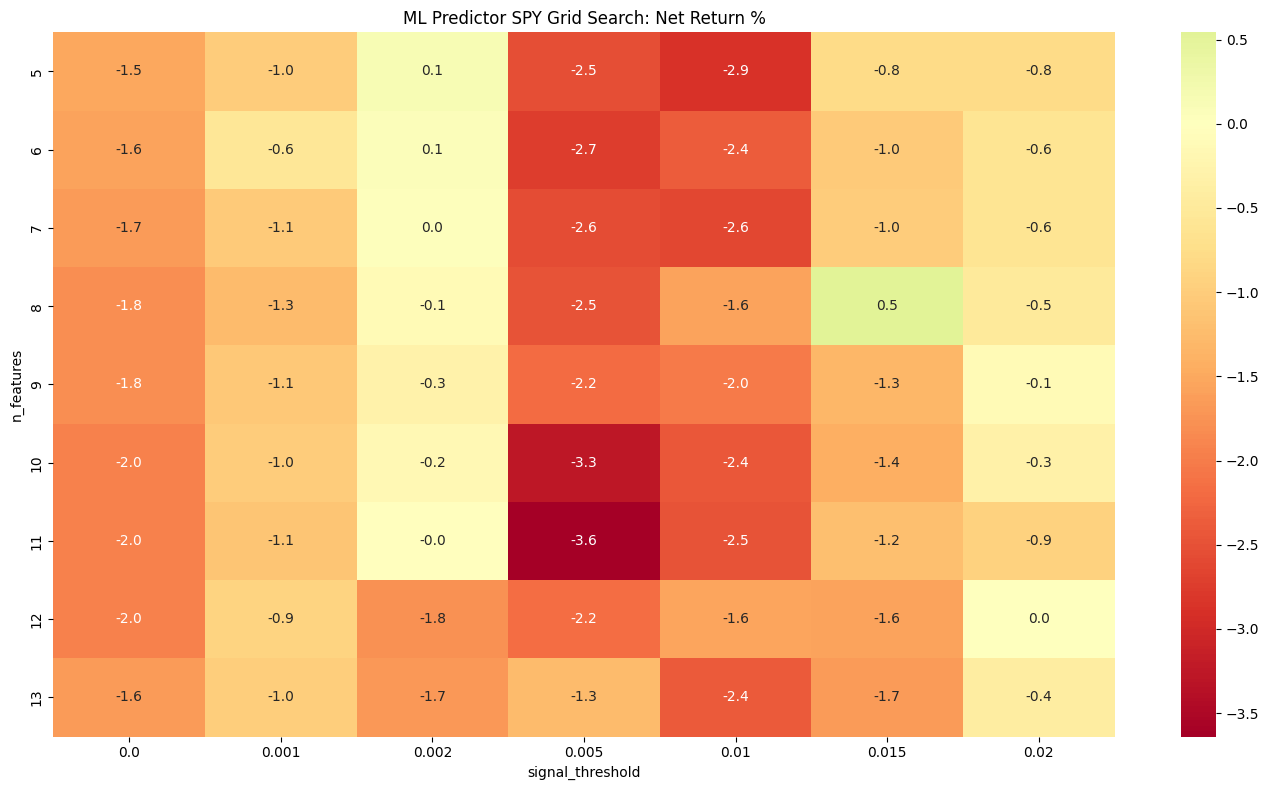

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ML_predictor import MLPredictorStrategy
from src.backtest.vector_backtester import PortfolioVectorEngine

# signal_thresholds = [0, 0.001, 0.003, 0.005, 0.007, 0.010, 0.0125, 0.0150, 0.175, 0.020]
signal_thresholds = [0, 0.001, 0.002, 0.005, 0.010, 0.0150, 0.020]
# signal_thresholds = [0, 0.001, 0.002, 0.005, 0.010]
# signal_thresholds = [0.001, 0.002, 0.005]


n_features_values = [5, 6, 7, 8, 9, 10, 11, 12, 13]
# n_features_values = [7, 8, 9, 10, 11]
# n_features_values = [7, 8, 9]


grid_records = []

for n_features in n_features_values:
    for signal_threshold in signal_thresholds:
        params = {
            "symbol": "SPY",
            "start_date": "2018-01-01",
            "end_date": "2019-01-01",
            "signal_threshold": signal_threshold,
            "n_features": n_features,
            "position_size": 0.10,
            "training_years": 10,
            "max_iter": 5000,
            "verbose": False
        }

        strategy = MLPredictorStrategy(params=params)
        dataset = strategy.prepare_dataset()
        weights = strategy.generate_signals(dataset)

        if weights.empty:
            continue

        prices_run = dataset[["Open"]].rename(columns={"Open": "SPY"}).loc[weights.index]

        engine_run = PortfolioVectorEngine(
            prices=prices_run,
            signals=weights,
            asset_class="STK",
            initial_capital=100000,
            execution_delay=0,
        )

        stats_run = engine_run.run()
        net_return_pct = (stats_run["net_equity"].iloc[-1] / 100000 - 1) * 100
        gross_return_pct = (stats_run["gross_equity"].iloc[-1] / 100000 - 1) * 100

        grid_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "net_return_pct": net_return_pct,
            "gross_return_pct": gross_return_pct,
            "final_net_equity": stats_run["net_equity"].iloc[-1],
            "final_gross_equity": stats_run["gross_equity"].iloc[-1],
        })

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="signal_threshold", values="net_return_pct")

display(grid_df.sort_values(["n_features", "signal_threshold"]).reset_index(drop=True))

plt.figure(figsize=(14, 8))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title("ML Predictor SPY Grid Search: Net Return %")
plt.xlabel("signal_threshold")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

🧠 Predicting 2018-12-31 |  251/251 |  last: 0.32s |  elapsed: 2m 21.7s
✅ Prediction complete. Took 2m 22.1s

🧠 Predicting 2018-12-31 |  251/251 |  last: 0.44s |  elapsed: 2m 49.1s
✅ Prediction complete. Took 2m 49.3s

🧠 Predicting 2018-12-31 |  251/251 |  last: 0.24s |  elapsed: 4m 24.1s
✅ Prediction complete. Took 4m 24.3s

🧠 Predicting 2018-12-31 |  251/251 |  last: 2.02s |  elapsed: 6m 38.8s
✅ Prediction complete. Took 6m 39.9s

🧠 Predicting 2018-12-31 |  251/251 |  last: 1.18s |  elapsed: 6m 23.2s
✅ Prediction complete. Took 6m 25.0s

🧠 Predicting 2018-12-31 |  251/251 |  last: 0.28s |  elapsed: 3m 18.2s
✅ Prediction complete. Took 3m 18.6s

🧠 Predicting 2018-12-31 |  251/251 |  last: 0.41s |  elapsed: 3m 24.3s
✅ Prediction complete. Took 3m 24.7s

🧠 Predicting 2018-12-31 |  251/251 |  last: 1.21s |  elapsed: 5m 44.3s
✅ Prediction complete. Took 5m 45.3s

🧠 Predicting 2018-12-31 |  251/251 |  last: 1.45s |  elapsed: 7m 30.9s
✅ Prediction complete. Took 7m 32.5s

🧠 Predicting 2018-1

,n_features,signal_threshold,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,1,0.001,-0.456244,-0.384330,99543.756262,99615.670276
1,1,0.002,-0.456244,-0.384330,99543.756262,99615.670276
2,1,0.003,-0.749846,-0.681979,99250.154382,99318.021375
3,1,0.004,-1.953009,-1.880608,98046.991355,98119.391504
4,1,0.005,-1.124220,-1.063860,98875.779806,98936.140234
5,2,0.001,-0.305634,-0.229162,99694.366328,99770.838271
6,2,0.002,-0.456244,-0.384330,99543.756262,99615.670276
7,2,0.003,-1.423523,-1.341909,98576.477364,98658.091227
8,2,0.004,-0.788135,-0.696733,99211.864977,99303.266650
9,2,0.005,-1.587669,-1.525528,98412.330778,98474.472307


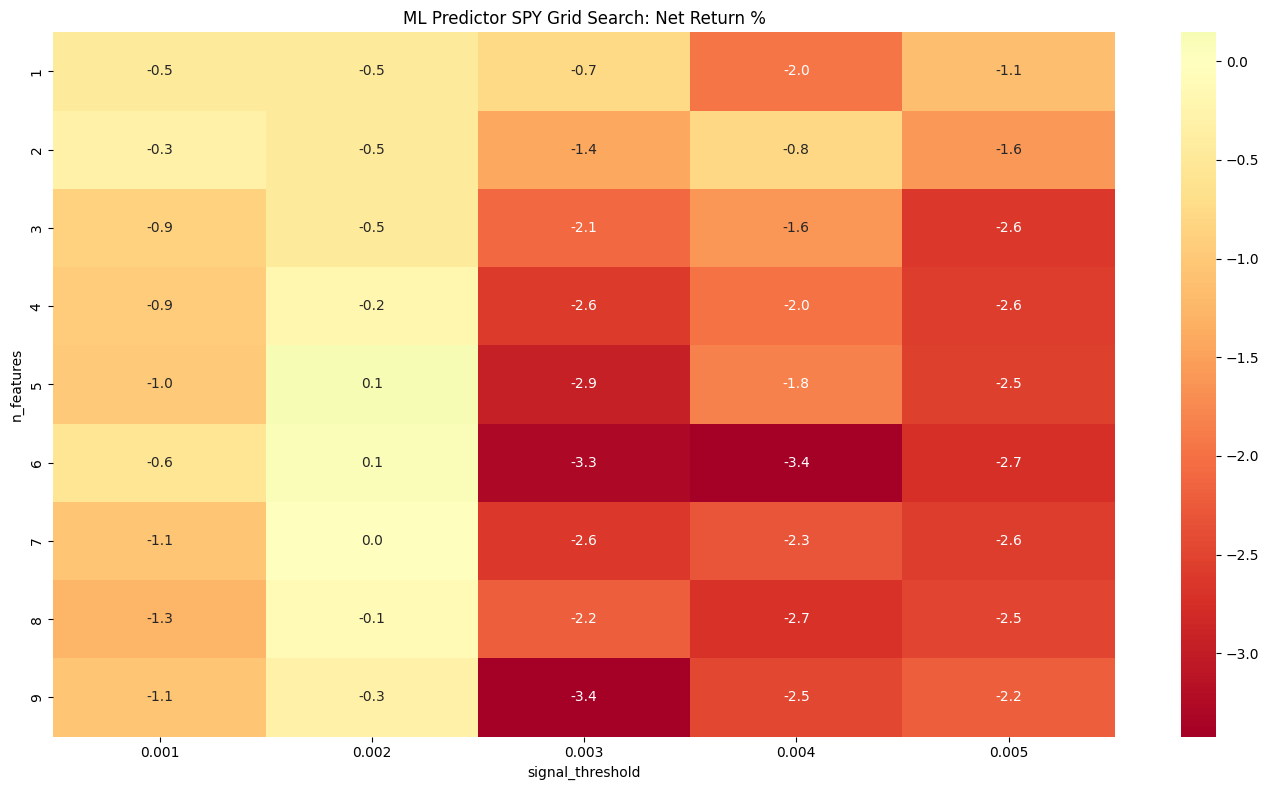

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ML_predictor import MLPredictorStrategy
from src.backtest.vector_backtester import PortfolioVectorEngine

# signal_thresholds = [0, 0.001, 0.003, 0.005, 0.007, 0.010, 0.0125, 0.0150, 0.175, 0.020]
# signal_thresholds = [0, 0.001, 0.002, 0.005, 0.010, 0.0150, 0.020]
# signal_thresholds = [0, 0.001, 0.002, 0.005, 0.010]
# signal_thresholds = [0.001, 0.002, 0.005]
signal_thresholds = [0.001, 0.002, 0.003, 0.004, 0.005]


# n_features_values = [5, 6, 7, 8, 9, 10, 11, 12, 13]
# n_features_values = [7, 8, 9, 10, 11]
# n_features_values = [7, 8, 9]
n_features_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]


grid_records = []

for n_features in n_features_values:
    for signal_threshold in signal_thresholds:
        params = {
            "symbol": "SPY",
            "start_date": "2018-01-01",
            "end_date": "2019-01-01",
            "signal_threshold": signal_threshold,
            "n_features": n_features,
            "position_size": 0.10,
            "training_years": 10,
            "max_iter": 5000,
            "verbose": False
        }

        strategy = MLPredictorStrategy(params=params)
        dataset = strategy.prepare_dataset()
        weights = strategy.generate_signals(dataset)

        if weights.empty:
            continue

        prices_run = dataset[["Open"]].rename(columns={"Open": "SPY"}).loc[weights.index]

        engine_run = PortfolioVectorEngine(
            prices=prices_run,
            signals=weights,
            asset_class="STK",
            initial_capital=100000,
            execution_delay=0,
        )

        stats_run = engine_run.run()
        net_return_pct = (stats_run["net_equity"].iloc[-1] / 100000 - 1) * 100
        gross_return_pct = (stats_run["gross_equity"].iloc[-1] / 100000 - 1) * 100

        grid_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "net_return_pct": net_return_pct,
            "gross_return_pct": gross_return_pct,
            "final_net_equity": stats_run["net_equity"].iloc[-1],
            "final_gross_equity": stats_run["gross_equity"].iloc[-1],
        })

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="signal_threshold", values="net_return_pct")

display(grid_df.sort_values(["n_features", "signal_threshold"]).reset_index(drop=True))

plt.figure(figsize=(14, 8))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title("ML Predictor SPY Grid Search: Net Return %")
plt.xlabel("signal_threshold")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

##### Function and parallelisation:

In [4]:
from joblib import Parallel, delayed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ML_predictor import MLPredictorStrategy
from src.backtest.vector_backtester import PortfolioVectorEngine

def run_grid_case(symbol, start_date =  "2018-01-01", end_date = "2019-01-01", n_features = 6, signal_threshold = 0.001, position_size = 1.00, training_years = 5, verbose = False):
    params = {
        "symbol": symbol,
        "start_date": "2018-01-01",
        "end_date": "2019-01-01",
        "signal_threshold": signal_threshold,
        "n_features": n_features,
        "position_size": position_size,
        "training_years": 5,
        "max_iter": 5000,
        "verbose": False
    }

    strategy = MLPredictorStrategy(params=params)
    dataset = strategy.prepare_dataset()
    weights = strategy.generate_signals(dataset, show_progress=False)

    if weights.empty:
        return None

    prices_run = dataset[["Open"]].rename(columns={"Open": symbol}).loc[weights.index]

    initial_capital = 100
    engine_run = PortfolioVectorEngine(
        prices=prices_run,
        signals=weights,
        asset_class="STK",
        initial_capital=initial_capital,
        execution_delay=0,
    )

    stats_run = engine_run.run()

    return {
        "n_features": n_features,
        "signal_threshold": signal_threshold,
        "net_return_pct": (stats_run["net_equity"].iloc[-1] / initial_capital - 1) * 100,
        "gross_return_pct": (stats_run["gross_equity"].iloc[-1] / initial_capital - 1) * 100,
        "final_net_equity": stats_run["net_equity"].iloc[-1],
        "final_gross_equity": stats_run["gross_equity"].iloc[-1],
    }


🧠 Predicting 2018-12-26 |  248/251 |  last: 0.80s |  elapsed: 6m 35.2s
✅ Prediction complete. Took 6m 35.3s

🧠 Predicting 2018-12-31 |  251/251 |  last: 1.63s |  elapsed: 6m 39.4s
✅ Prediction complete. Took 6m 40.8s

🧠 Predicting 2018-01-09 |  6/251 |  last: 2.60s |  elapsed: 8.4s 56.2s
✅ Prediction complete. Took 6m 58.0s

🧠 Predicting 2018-11-28 |  230/251 |  last: 3.58s |  elapsed: 15m 13.5s
✅ Prediction complete. Took 8m 25.8s

🧠 Predicting 2018-01-29 |  19/251 |  last: 1.45s |  elapsed: 32.6s.1sss 250/251 |  last: 1.64s |  elapsed: 8m 44.0s
✅ Prediction complete. Took 8m 46.9s

🧠 Predicting 2018-02-21 |  35/251 |  last: 2.49s |  elapsed: 1m 16.0s2s
✅ Prediction complete. Took 16m 36.4s

🧠 Predicting 2018-12-31 |  251/251 |  last: 1.95s |  elapsed: 7m 26.8ss 112/251 |  last: 5.81s |  elapsed: 13m 12.6s 75/251 |  last: 4.88s |  elapsed: 4m 49.9s
✅ Prediction complete. Took 7m 29.4s

🧠 Predicting 2018-11-14 |  221/251 |  last: 1.26s |  elapsed: 6m 38.3ss 113/251 |  last: 1.60s |  el

,n_features,signal_threshold,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,1,0.001,-99.905055,-99.905055,94.944884,94.944884
1,1,0.002,-99.910888,-99.907971,89.112119,92.028969
2,1,0.003,-99.912704,-99.903312,87.296035,96.687742
3,1,0.004,-99.926740,-99.918088,73.260043,81.912252
4,1,0.005,-99.922178,-99.914236,77.822238,85.763932
5,2,0.001,-99.905055,-99.905055,94.944884,94.944884
6,2,0.002,-99.902479,-99.895958,97.520695,104.042435
7,2,0.003,-99.921656,-99.912630,78.344404,87.370373
8,2,0.004,-99.924872,-99.917297,75.127860,82.703038
9,2,0.005,-99.925983,-99.917321,74.017114,82.679380


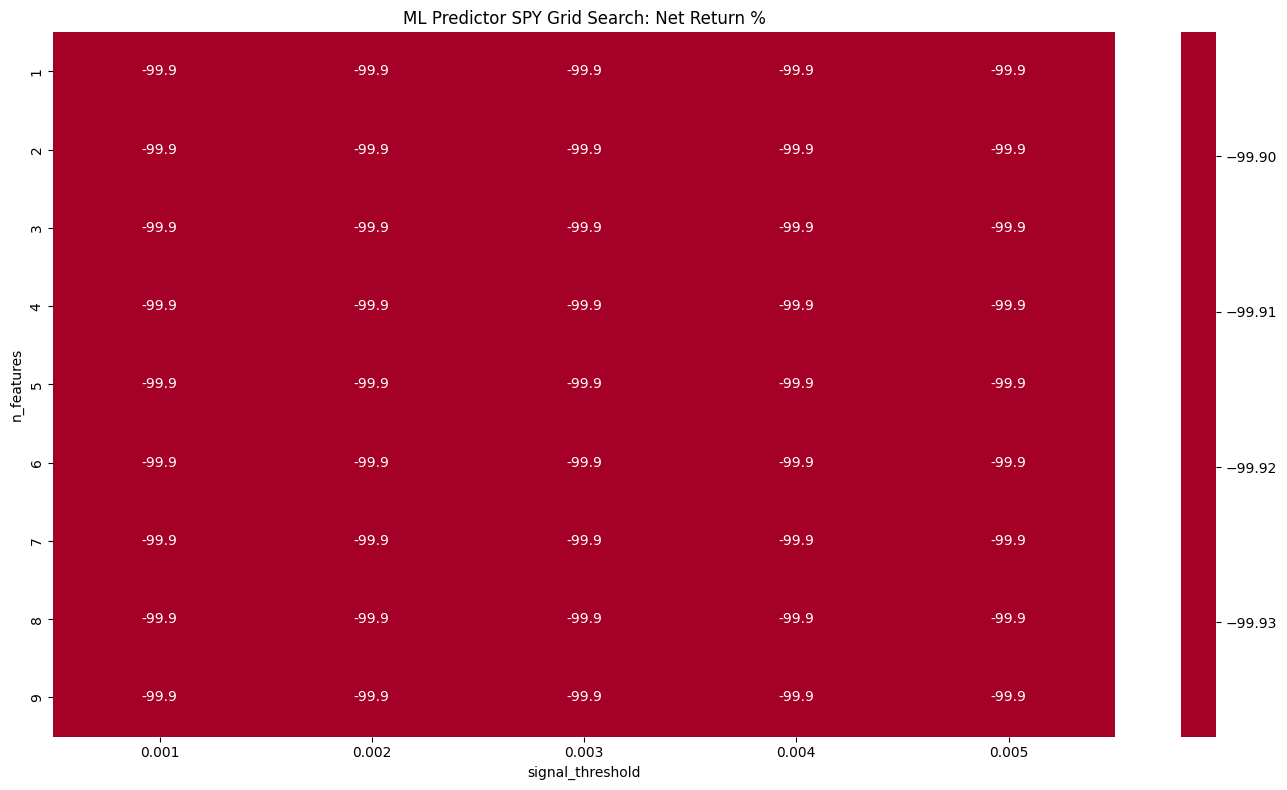

In [ ]:
symbol = "SPY"
signal_threshold_list = [0.001, 0.002, 0.003, 0.004, 0.005]
n_features_list = [1, 2, 3, 4, 5, 6, 7, 8, 9]


cases = [
    (n_features, signal_threshold)
    for n_features in n_features_list
    for signal_threshold in signal_threshold_list
]

grid_records = Parallel(n_jobs=4, backend="threading")(
    delayed(run_grid_case)(symbol, n_features, signal_threshold)
    for n_features, signal_threshold in cases
)

grid_records = [record for record in grid_records if record is not None]

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="signal_threshold", values="net_return_pct")

display(grid_df.sort_values(["n_features", "signal_threshold"]).reset_index(drop=True))

plt.figure(figsize=(14, 8))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Net Return %")
plt.xlabel("signal_threshold")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()



,n_features,signal_threshold,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,1,0.001,-99.905055,-99.905055,94.944884,94.944884
1,1,0.002,-99.910888,-99.907971,89.112119,92.028969
2,1,0.003,-99.912704,-99.903312,87.296035,96.687742
3,1,0.004,-99.926740,-99.918088,73.260043,81.912252
4,1,0.005,-99.922178,-99.914236,77.822238,85.763932
5,2,0.001,-99.905055,-99.905055,94.944884,94.944884
6,2,0.002,-99.902479,-99.895958,97.520695,104.042435
7,2,0.003,-99.921656,-99.912630,78.344404,87.370373
8,2,0.004,-99.924872,-99.917297,75.127860,82.703038
9,2,0.005,-99.925983,-99.917321,74.017114,82.679380


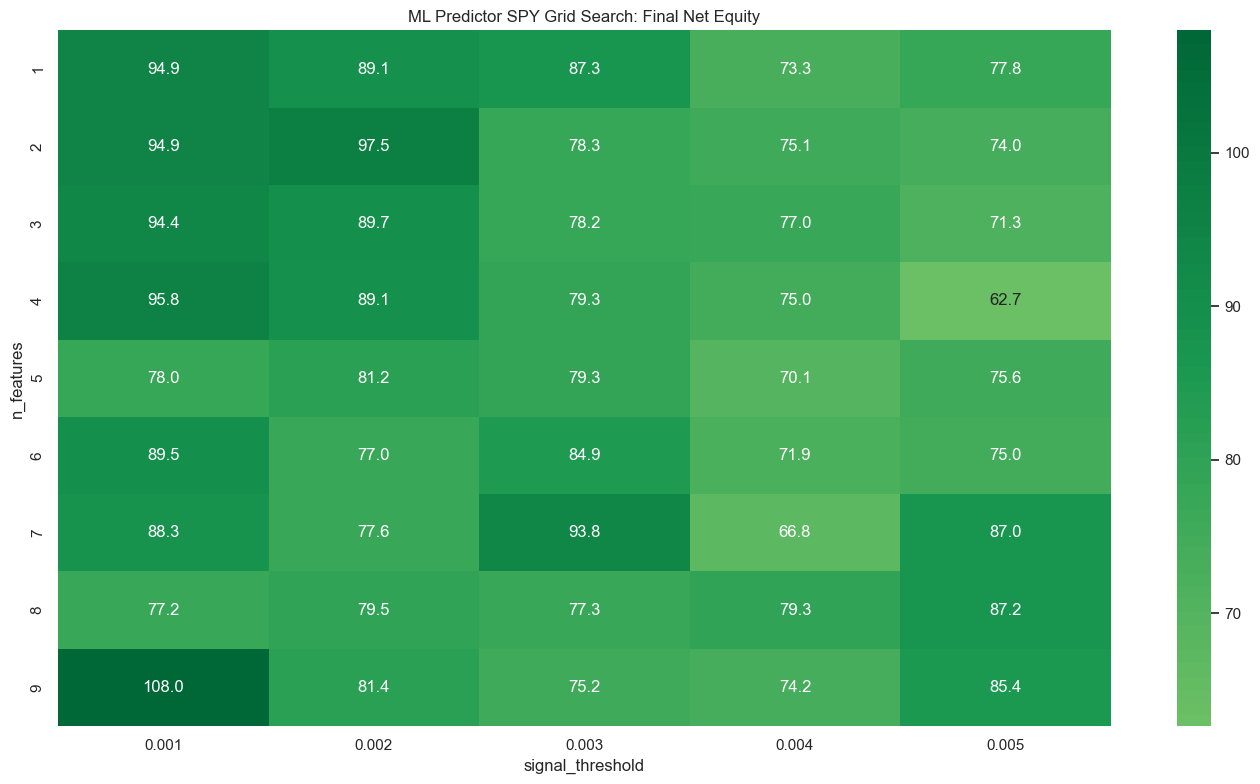

In [25]:
symbol = "SPY"
signal_threshold_list = [0.001, 0.002, 0.003, 0.004, 0.005]
n_features_list = [1, 2, 3, 4, 5, 6, 7, 8, 9]


# cases = [
#     (n_features, signal_threshold)
#     for n_features in n_features_list
#     for signal_threshold in signal_threshold_list
# ]

# grid_records = Parallel(n_jobs=4, backend="threading")(
#     delayed(run_grid_case)(symbol, n_features, signal_threshold)
#     for n_features, signal_threshold in cases
# )

# grid_records = [record for record in grid_records if record is not None]

# grid_df = pd.DataFrame(grid_records)
# grid_pivot = grid_df.pivot(index="n_features", columns="signal_threshold", values="net_return_pct")
grid_pivot_abs = grid_df.pivot(index="n_features", columns="signal_threshold", values="final_net_equity")

display(grid_df.sort_values(["n_features", "signal_threshold"]).reset_index(drop=True))

plt.figure(figsize=(14, 8))
sns.heatmap(grid_pivot_abs, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Final Net Equity")
plt.xlabel("signal_threshold")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

#### EWZ

⬇️ Downloading data for EWZ from 2007-01-01 to 2020-01-01...


[*********************100%***********************]  1 of 1 completed

🧪 Assigning singal to historic dataset...
🧪 Computing technical indicators...


🧹 Cleaning dataset...
☑️ 71 NaN, non-numeric and auxiliary columns have been removed:
['Open_t+1', 'Open_t+2', 'ACOS', 'ASIN', 'CPR_WIDTH_CLASS', 'CPR_POSITION', 'HILOl_13_21', 'HILOs_13_21', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'SUPERTl_7_3.0', 'SUPERTs_7_3.0', 'VFI_130', 'TOS_STDEVALL_180_LR', 'TOS_STDEVALL_180_L_1', 'TOS_STDEVALL_180_U_1', 'TOS_STDEVALL_180_L_2', 'TOS_STDEVALL_180_U_2', 'TOS_STDEVALL_180_L_3', 'TOS_STDEVALL_180_U_3', 'TOS_STDEVALL_252_LR', 'TOS_STDEVALL_252_L_1', 'TOS_STDEVALL_252_U_1', 'TOS_STDEVALL_252_L_2', 'TOS_STDEVALL_252_U_2', 'TOS_STDEVALL_252_L_3', 'TOS_STDEVALL_252_U_3', 'TOS_STDEVALL_500_LR', 'TOS_STDEVALL_500_L_1', 'TOS_STDEVALL_500_U_1', 'TOS_STDEVALL_500_L_2', 'TOS_STDEVALL_500_U_2', 'TOS_STDEVALL_500_L_3', 'TOS_STDEVALL_500_U_3', 'TOS_STDEVALL_1000_LR', 'TOS_STDEVALL_1000_L_1', 'TOS_STDEVALL_1000_U_1', 'TOS_STDEVALL_1000_L_2', 'TOS_STDEVALL_1000_U_2', 'TOS_STDEVALL_1000_L_3', 'TOS_STDEVALL_1000_U_3', 'TOS_STDEVALL_

,EWZ
Date,
2018-01-02,0.1
2018-01-03,0.1
2018-01-04,0.1
2018-01-05,0.1
2018-01-08,-0.1


,EWZ
Date,
2019-12-24,0.1
2019-12-26,0.1
2019-12-27,0.1
2019-12-30,0.1
2019-12-31,0.1


EWZ 
 0.1    390
-0.1    113
Name: count, dtype: int64


📊 --- QUICK PORTFOLIO RESULTS: EWZ MLP Walk Forward ---
   Frictionless Return: -3.34%
   Net Strategy Return: -4.14% (EW Benchmark: 21.04%)
   Max Drawdown:        -5.57%
   Win Rate (Bars):     45.9%
   Total Fees Paid:     $792.82
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/EWZ_MLP_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


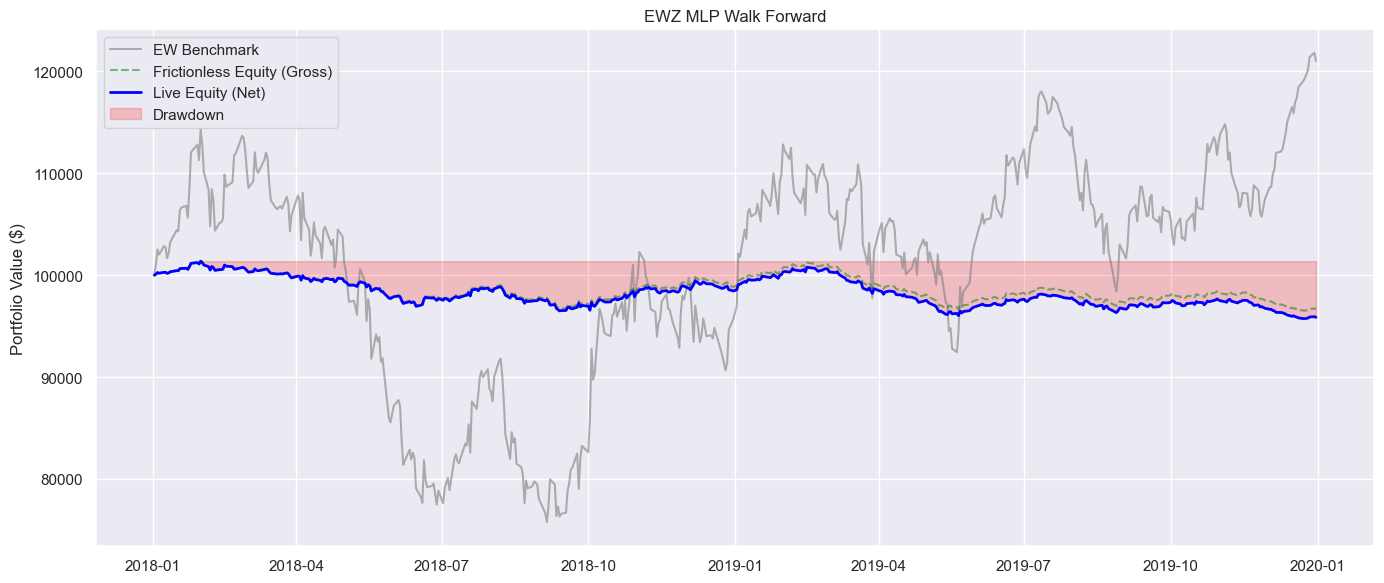

In [1]:
from ML_predictor import MLPredictorStrategy

strategy = MLPredictorStrategy(params={
    "symbol": "EWZ",
    "start_date": "2018-01-01",
    "end_date": "2020-01-01",
    "signal_threshold": 0.002,
    "n_features": 8,
    "position_size": 0.10,
    "training_years": 10,
    "max_iter": 5000,
})

df = strategy.prepare_dataset()
df.head(20)


weights = strategy.generate_signals(df)
display(weights.head())
display(weights.tail())
display(weights.value_counts())


from src.backtest.vector_backtester import PortfolioVectorEngine

prices = df[["Open"]].rename(columns={"Open": "EWZ"}).loc[weights.index]

engine = PortfolioVectorEngine(
    prices=prices,
    signals=weights,
    asset_class="STK",
    initial_capital=100000,
    execution_delay=0,
)

stats = engine.run()
engine.tearsheet("EWZ MLP Walk Forward")


#### –––––––––– TEST NEW SCRIPT –––––––––

##### ECH

In [ ]:
import importlib
import ML_predictor
importlib.reload(ML_predictor)
from ML_predictor import MLPredictorStrategy

strategy_ECH = MLPredictorStrategy(params={
    "symbol": "ECH",
    "start_date": "2023-01-01",
    "end_date": "2024-01-01",
    "signal_threshold": 0.002,
    "n_features": 8,
    "position_size": 0.30,
    "training_years": 5,
    "max_iter": 5000,
    "verbose": True
})

df_ECH = strategy_ECH.prepare_dataset()
print("🫧 Clean dataset:")
display(df_ECH)


[*********************100%***********************]  1 of 1 completed

⬇️ Downloading data for ECH from 2017-01-01 to 2024-01-01...
🧪 Assigning singal to historic dataset...
🧪 Computing technical indicators...


🧹 Cleaning dataset...
☑️ 44 NaN, non-numeric and auxiliary columns have been removed:
['Open_t+1', 'Open_t+2', 'ACOS', 'ASIN', 'CPR_WIDTH_CLASS', 'CPR_POSITION', 'HILOl_13_21', 'HILOs_13_21', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'SUPERTl_7_3.0', 'SUPERTs_7_3.0', 'TRIXs_30_9', 'VFI_130', 'TOS_STDEVALL_30_LR', 'TOS_STDEVALL_30_L_1', 'TOS_STDEVALL_30_U_1', 'TOS_STDEVALL_30_L_2', 'TOS_STDEVALL_30_U_2', 'TOS_STDEVALL_30_L_3', 'TOS_STDEVALL_30_U_3', 'TOS_STDEVALL_90_LR', 'TOS_STDEVALL_90_L_1', 'TOS_STDEVALL_90_U_1', 'TOS_STDEVALL_90_L_2', 'TOS_STDEVALL_90_U_2', 'TOS_STDEVALL_90_L_3', 'TOS_STDEVALL_90_U_3', 'TOS_STDEVALL_252_LR', 'TOS_STDEVALL_252_L_1', 'TOS_STDEVALL_252_U_1', 'TOS_STDEVALL_252_L_2', 'TOS_STDEVALL_252_U_2', 'TOS_STDEVALL_252_L_3', 'TOS_STDEVALL_252_U_3', 'TOS_STDEVALL_1000_LR', 'TOS_STDEVALL_1000_L_1', 'TOS_STDEVALL_1000_U_1', 'TOS_STDEVALL_1000_L_2', 'TOS_STDEVALL_1000_U_2', 'TOS_STDEVALL_1000_L_3', 'TOS_STDEVALL_1000_U_3']
☑️ 88 rows wit

ECH,Open,High,Low,Close,Volume,Signal,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,...,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,DPO_20,ISA_9,ISB_26,ITS_9,IKS_26
Date,,,,,,,,,,,,,,,,,,,,,
2017-05-10,31.770546,31.949324,31.666256,31.815239,369500,-1.0,31.771539,32.199243,31.343836,0.427704,...,31.811514,-74.820322,31.861018,31.634272,-1.338345,-1.299504,31.805931,30.858028,31.912076,32.586224
2017-05-11,31.971674,32.023820,31.725854,31.852488,217600,1.0,31.766078,32.185133,31.347024,0.419054,...,31.863662,-73.021622,31.842734,31.626543,-1.204815,-1.247357,31.899045,30.869199,31.912076,32.586224
2017-05-12,31.882280,32.083407,31.882280,32.023815,185500,1.0,31.756642,32.163154,31.350130,0.406512,...,32.003329,-59.166974,31.860071,31.786808,-0.914444,-1.041764,32.038713,31.018184,31.912076,32.586224
2017-05-15,32.210040,32.522902,32.195141,32.508003,454900,-1.0,31.906615,32.319299,31.493932,0.412684,...,32.433512,-20.874525,31.964764,32.114320,-0.228447,-0.525544,32.202598,31.182068,31.908352,32.586224
2017-05-16,32.612292,32.694233,32.426064,32.522903,472100,-1.0,32.126115,32.529165,31.723066,0.403049,...,32.541526,-12.234069,32.062956,32.317274,-0.201784,-0.488297,32.305025,31.204415,31.994018,32.586224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,26.202141,26.325379,25.993586,26.097864,387900,1.0,26.281633,26.828833,25.734433,0.547200,...,26.128673,-44.215499,26.285608,26.202793,0.818889,1.293301,23.699993,24.371212,25.991565,25.647711
2023-12-26,26.154742,26.486535,26.069424,26.391737,192700,1.0,26.261086,26.799613,25.722558,0.538527,...,26.334858,-30.100326,26.321567,26.203709,1.118921,1.452929,23.699993,24.154538,26.179977,25.652421
2023-12-27,26.458095,26.742488,25.984106,26.391737,1234500,0.0,26.227421,26.780605,25.674236,0.553184,...,26.377517,-30.100326,26.335177,26.317182,1.120218,1.357310,23.699993,24.154538,26.434902,25.850255


🧠 Predicting 2023-12-29 |  250/250 |  last: 0.80s |  elapsed: 4m 44.9s
✅ Prediction complete. Took 4m 45.6s



ECH 
-0.3    145
 0.3    105
Name: count, dtype: int64


📊 --- QUICK PORTFOLIO RESULTS: ECH MLP Walk Forward ---
   Frictionless Return: 49.32%
   Net Strategy Return: 47.43% (EW Benchmark: 10.00%)
   Max Drawdown:        -1.90%
   Win Rate (Bars):     64.4%
   Total Fees Paid:     $1,894.05
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_MLP_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


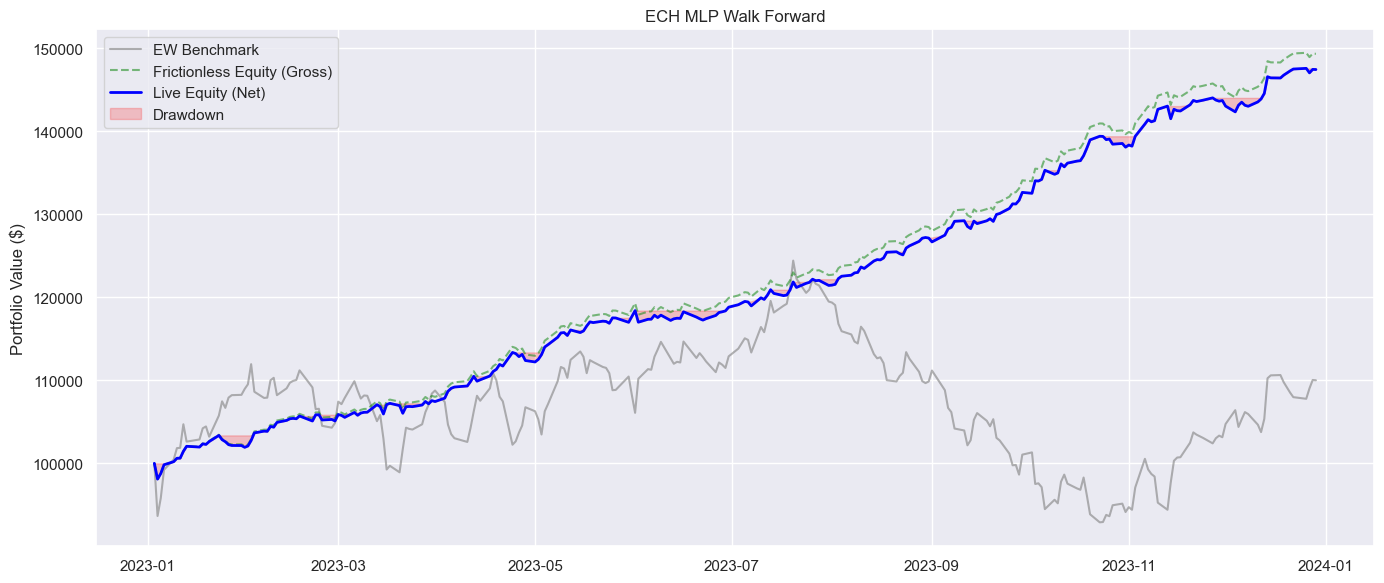

In [11]:
df = df_ECH.copy()

weights = strategy_ECH.generate_signals(df)
print("🏋️‍♂️ Weights summary:")
display(weights.value_counts())


from src.backtest.vector_backtester import PortfolioVectorEngine

prices = df[["Open"]].rename(columns={"Open": "ECH"}).loc[weights.index]

engine = PortfolioVectorEngine(
    prices=prices,
    signals=weights,
    asset_class="STK",
    initial_capital=100000,
    execution_delay=0,
)

stats = engine.run()
engine.tearsheet("ECH MLP Walk Forward")


##### EWZ

In [ ]:
import importlib
import ML_predictor
importlib.reload(ML_predictor)
from ML_predictor import MLPredictorStrategy

strategy_EWZ = MLPredictorStrategy(params={
    "symbol": "EWZ",
    "start_date": "2023-01-01",
    "end_date": "2024-01-01",
    "signal_threshold": 0.001,
    "n_features": 8,
    "position_size": 0.10,
    "training_years": 5,
    "max_iter": 5000,
    "verbose": True
})

df_EWZ = strategy_EWZ.prepare_dataset()
print("🫧 Clean dataset:")
display(df_EWZ)


[*********************100%***********************]  1 of 1 completed

⬇️ Downloading data for EWZ from 2017-01-01 to 2024-01-01...
🧪 Assigning singal to historic dataset...
🧪 Computing technical indicators...


🧹 Cleaning dataset...
☑️ 58 NaN, non-numeric and auxiliary columns have been removed:
['Open_t+1', 'Open_t+2', 'ACOS', 'ASIN', 'CPR_WIDTH_CLASS', 'CPR_POSITION', 'HILOl_13_21', 'HILOs_13_21', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'SUPERTl_7_3.0', 'SUPERTs_7_3.0', 'TRIXs_30_9', 'VFI_130', 'TOS_STDEVALL_90_LR', 'TOS_STDEVALL_90_L_1', 'TOS_STDEVALL_90_U_1', 'TOS_STDEVALL_90_L_2', 'TOS_STDEVALL_90_U_2', 'TOS_STDEVALL_90_L_3', 'TOS_STDEVALL_90_U_3', 'TOS_STDEVALL_180_LR', 'TOS_STDEVALL_180_L_1', 'TOS_STDEVALL_180_U_1', 'TOS_STDEVALL_180_L_2', 'TOS_STDEVALL_180_U_2', 'TOS_STDEVALL_180_L_3', 'TOS_STDEVALL_180_U_3', 'TOS_STDEVALL_252_LR', 'TOS_STDEVALL_252_L_1', 'TOS_STDEVALL_252_U_1', 'TOS_STDEVALL_252_L_2', 'TOS_STDEVALL_252_U_2', 'TOS_STDEVALL_252_L_3', 'TOS_STDEVALL_252_U_3', 'TOS_STDEVALL_500_LR', 'TOS_STDEVALL_500_L_1', 'TOS_STDEVALL_500_U_1', 'TOS_STDEVALL_500_L_2', 'TOS_STDEVALL_500_U_2', 'TOS_STDEVALL_500_L_3', 'TOS_STDEVALL_500_U_3', 'TOS_STDEVALL_

EWZ,Open,High,Low,Close,Volume,Signal,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,...,ISB_26,ITS_9,IKS_26,TOS_STDEVALL_30_LR,TOS_STDEVALL_30_L_1,TOS_STDEVALL_30_U_1,TOS_STDEVALL_30_L_2,TOS_STDEVALL_30_U_2,TOS_STDEVALL_30_L_3,TOS_STDEVALL_30_U_3
Date,,,,,,,,,,,,,,,,,,,,,
2017-05-10,23.505025,23.682212,23.492805,23.572235,15761200,1.0,22.970610,23.476857,22.464363,0.506247,...,23.388937,22.970403,22.857369,22.818149,22.449269,23.187029,22.080389,23.555909,21.711509,23.924789
2017-05-11,23.737205,23.877736,23.566127,23.804415,12192200,1.0,23.193012,23.686283,22.699741,0.493271,...,23.492804,23.172035,22.955131,22.978217,22.571433,23.385001,22.164648,23.791785,21.757864,24.198569
2017-05-12,24.116021,24.348198,24.085470,24.280991,22975300,1.0,23.469589,23.966227,22.972950,0.496638,...,23.520301,23.407266,23.190362,23.172816,22.685562,23.660070,22.198307,24.147325,21.711053,24.634579
2017-05-15,24.439848,24.598706,24.384858,24.531498,16380800,-1.0,23.820707,24.305417,23.335997,0.484710,...,23.520301,23.532520,23.315616,23.391684,22.816960,23.966407,22.242237,24.541131,21.667513,25.115855
2017-05-16,24.665919,24.720909,24.433742,24.708689,18132500,-1.0,24.139239,24.610780,23.667699,0.471541,...,23.520301,23.593622,23.376718,23.640353,22.980367,24.300338,22.320381,24.960324,21.660395,25.620310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,30.293752,30.574575,30.258648,30.381508,16014400,1.0,30.046104,30.568942,29.523265,0.522839,...,26.387629,29.381594,29.381594,29.805710,29.107426,30.503994,28.409142,31.202279,27.710858,31.900563
2023-12-26,30.697436,30.908054,30.618454,30.846624,15982400,1.0,30.257526,30.780612,29.734440,0.523086,...,26.387629,29.599186,29.548334,29.964170,29.228809,30.699530,28.493449,31.434890,27.758089,32.170250
2023-12-27,30.829075,31.013365,30.750094,30.951935,18672900,0.0,30.400233,30.905998,29.894468,0.505765,...,26.387629,30.143403,29.600989,30.110185,29.352190,30.868179,28.594195,31.626174,27.836201,32.384168


🧠 Predicting 2023-12-29 |  250/250 |  last: 0.53s |  elapsed: 2m 6.8ss
✅ Prediction complete. Took 2m 7.3s

𐄷 Weights summary:


EWZ 
 0.1    131
-0.1    119
Name: count, dtype: int64


📊 --- QUICK PORTFOLIO RESULTS: EWZ MLP Walk Forward ---
   Frictionless Return: 0.74%
   Net Strategy Return: 0.42% (EW Benchmark: 39.59%)
   Max Drawdown:        -2.39%
   Win Rate (Bars):     46.8%
   Total Fees Paid:     $317.21
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/EWZ_MLP_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


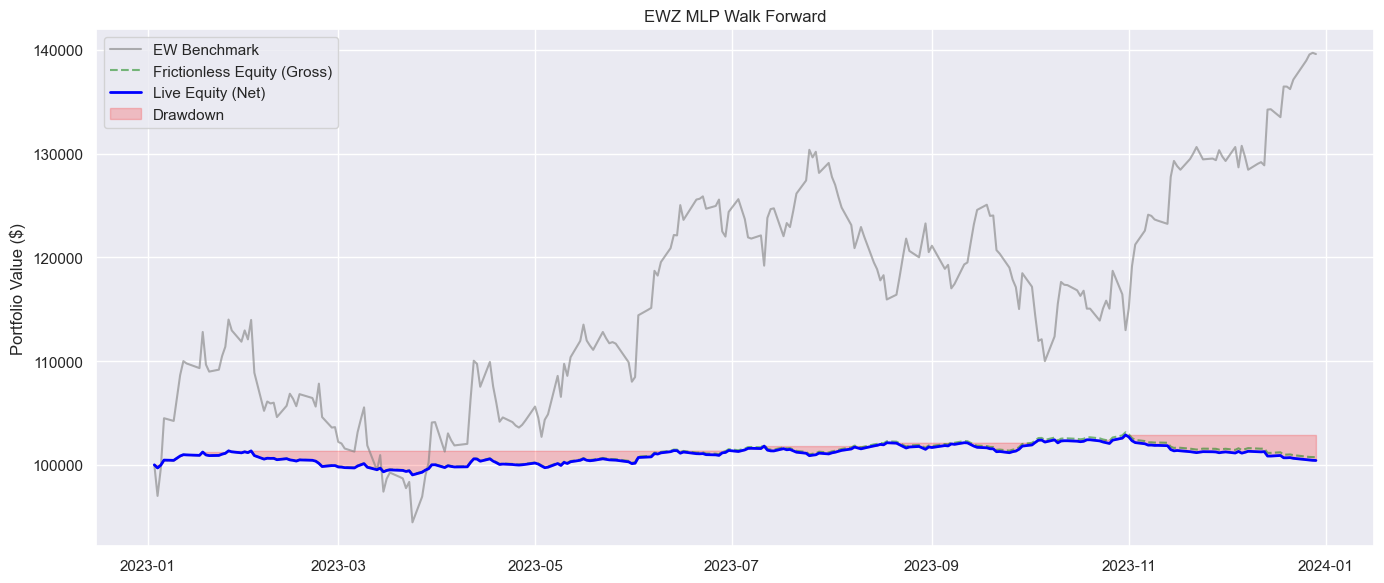

In [3]:
df = df_EWZ.copy()

weights = strategy_EWZ.generate_signals(df)
print("🏋️‍♂️ Weights summary:")
display(weights.value_counts())


from src.backtest.vector_backtester import PortfolioVectorEngine

prices = df[["Open"]].rename(columns={"Open": "EWZ"}).loc[weights.index]

engine = PortfolioVectorEngine(
    prices=prices,
    signals=weights,
    asset_class="STK",
    initial_capital=100000,
    execution_delay=0,
)

stats = engine.run()
engine.tearsheet("EWZ MLP Walk Forward")


#### –––––––– Functions and Parallelisation –––––––––

##### Functions

Function for single case. Prints stats and graph

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ML_predictor import MLPredictorStrategy
from src.backtest.vector_backtester import PortfolioVectorEngine

def run_single_case(symbol, start_date = "2018-01-01", end_date = "2019-01-01", n_features = 6, signal_threshold = 0.001, position_size = 1.00, initial_capital = 1000000, training_years = 5, verbose = False, show_progress = True):
    params = {
        "symbol": symbol,
        "start_date": start_date,
        "end_date": end_date,
        "signal_threshold": signal_threshold,
        "n_features": n_features,
        "position_size": position_size,
        "training_years": training_years,
        "max_iter": 5000,
        "verbose": verbose,
        "show_progress": show_progress
    }

    strategy = MLPredictorStrategy(params=params)
    dataset = strategy.prepare_dataset()
    weights = strategy.generate_signals(dataset, show_progress=True)

    if weights.empty:
        return None

    prices_run = dataset[["Open"]].rename(columns={"Open": symbol}).loc[weights.index]

    engine_run = PortfolioVectorEngine(
        prices=prices_run,
        signals=weights,
        asset_class="STK",
        initial_capital=initial_capital,
        execution_delay=0,
    )

    stats_run = engine_run.run()
    engine_run.tearsheet(f"{symbol} ML Walk Forward")


Example for single function:

🧠 Predicting 2018-12-31 |  251/251 |  last: 2.11s |  elapsed: 6m 29.6s
✅ Prediction complete. Took 6m 31.4s


📊 --- QUICK PORTFOLIO RESULTS: SPY ML Walk Forward ---
   Frictionless Return: -2.97%
   Net Strategy Return: -3.52% (EW Benchmark: -5.06%)
   Max Drawdown:        -19.78%
   Win Rate (Bars):     51.8%
   Total Fees Paid:     $5,461.18
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/SPY_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


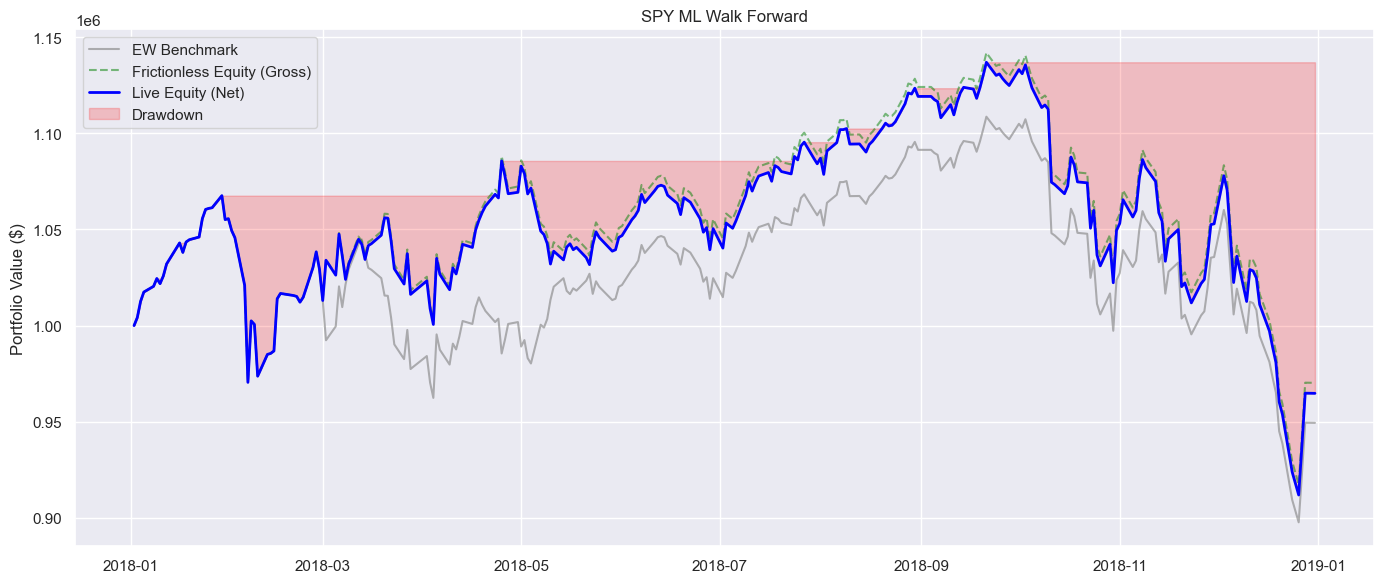

In [6]:
run_single_case("SPY", 9, 0.001)

Function for grid search – parallelisable

In [3]:
from joblib import Parallel, delayed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ML_predictor import MLPredictorStrategy
from src.backtest.vector_backtester import PortfolioVectorEngine

def run_grid_case(symbol, start_date =  "2018-01-01", end_date = "2019-01-01", n_features = 6, signal_threshold = 0.001, training_years = 5, position_size = 1.00, initial_capital = 1000000, verbose = False, show_progress=False):
    params = {
        "symbol": symbol,
        "start_date": start_date,
        "end_date": end_date,
        "signal_threshold": signal_threshold,
        "n_features": n_features,
        "position_size": position_size,
        "training_years": training_years,
        "max_iter": 5000,
        "verbose": verbose
    }

    strategy = MLPredictorStrategy(params=params)
    dataset = strategy.prepare_dataset()
    weights = strategy.generate_signals(dataset, show_progress=show_progress)

    if weights.empty:
        return None

    prices_run = dataset[["Open"]].rename(columns={"Open": symbol}).loc[weights.index]

    engine_run = PortfolioVectorEngine(
        prices=prices_run,
        signals=weights,
        asset_class="STK",
        initial_capital=initial_capital,
        execution_delay=0,
    )

    stats_run = engine_run.run()

    return {
        **params,
        "net_return_pct": (stats_run["net_equity"].iloc[-1] / initial_capital - 1) * 100,
        "gross_return_pct": (stats_run["gross_equity"].iloc[-1] / initial_capital - 1) * 100,
        "final_net_equity": stats_run["net_equity"].iloc[-1],
        "final_gross_equity": stats_run["gross_equity"].iloc[-1],
    }


Run grid search – example:

🧠 Predicting 2018-11-13 |  220/251 |  last: 24.16s |  elapsed: 791m 0.5ss
✅ Prediction complete. Took 791m 1.6s

🧠 Predicting 2018-12-31 |  251/251 |  last: 9.19s |  elapsed: 794m 28.8ss
✅ Prediction complete. Took 794m 32.1s

🧠 Predicting 2018-12-24 |  247/251 |  last: 17.53s |  elapsed: 800m 39.7s
✅ Prediction complete. Took 800m 46.7s

🧠 Predicting 2018-12-31 |  251/251 |  last: 19.33s |  elapsed: 802m 6.4ss
✅ Prediction complete. Took 802m 28.9s



,n_features,signal_threshold,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,7,0.001,0.440912,1.172219,1.004409e+06,1.011722e+06
1,7,0.002,-1.033786,-0.356542,9.896621e+05,9.964346e+05
2,7,0.003,0.222524,0.663578,1.002225e+06,1.006636e+06
3,8,0.001,4.434004,5.257136,1.044340e+06,1.052571e+06
4,8,0.002,-6.315285,-5.730783,9.368472e+05,9.426922e+05
5,8,0.003,-14.326629,-13.901016,8.567337e+05,8.609898e+05
6,9,0.001,2.210471,2.844667,1.022105e+06,1.028447e+06
7,9,0.002,-7.435198,-6.669675,9.256480e+05,9.333033e+05
8,9,0.003,-6.292644,-5.825806,9.370736e+05,9.417419e+05


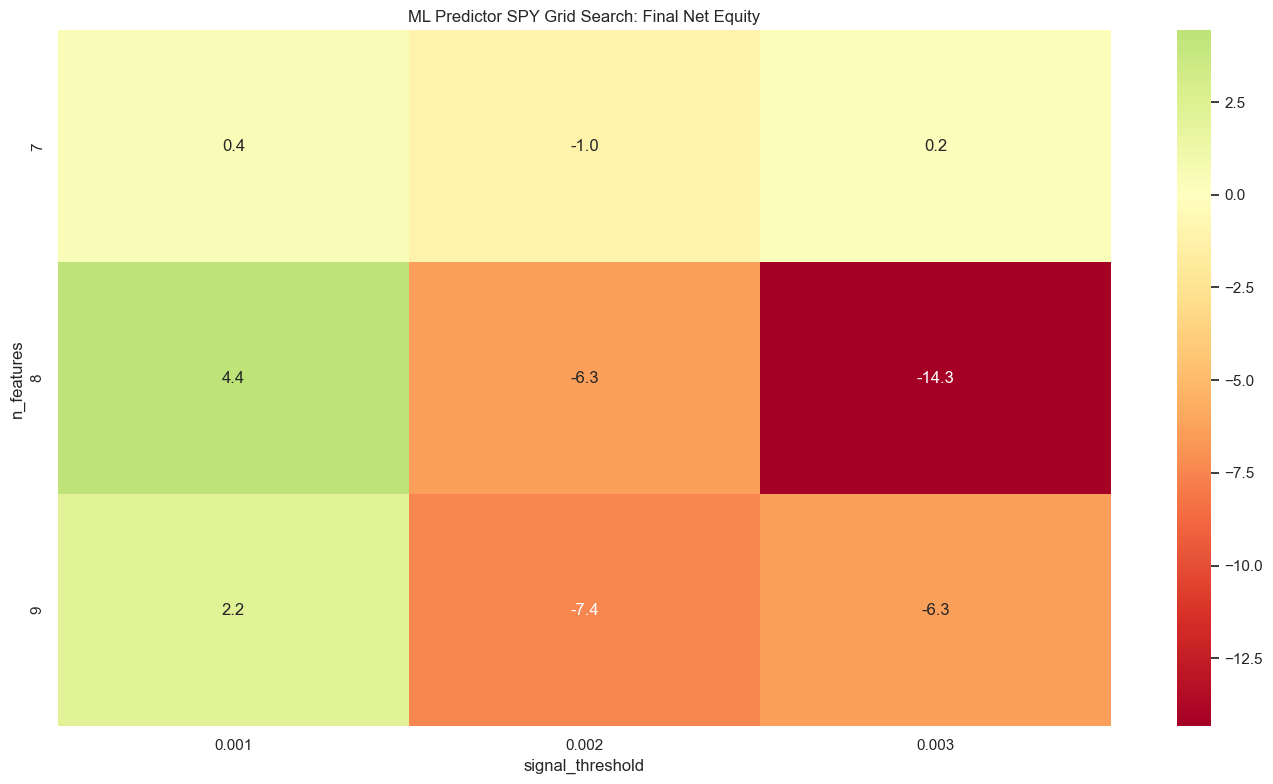

In [15]:
symbol = "SPY"
signal_threshold_list = [0.001, 0.002, 0.003]
n_features_list = [7, 8, 9]


cases = [
    (n_features, signal_threshold)
    for n_features in n_features_list
    for signal_threshold in signal_threshold_list
]

grid_records = Parallel(n_jobs=4, backend="threading")(
    delayed(run_grid_case)(symbol=symbol, n_features=n_features, signal_threshold=signal_threshold)
    for n_features, signal_threshold in cases
)

grid_records = [record for record in grid_records if record is not None]

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="signal_threshold", values="net_return_pct")

display(grid_df.sort_values(["n_features", "signal_threshold"]).reset_index(drop=True))

plt.figure(figsize=(14, 8))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Final Net Equity")
plt.xlabel("signal_threshold")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

#### ----------- ECH grid search with parralelisation ------------

,symbol,start_date,end_date,signal_threshold,n_features,position_size,training_years,max_iter,verbose,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2018-01-01,2019-01-01,0.002,3,1.0,1,5000,False,6.863289,8.293469,1.068633e+06,1.082935e+06
1,ECH,2018-01-01,2019-01-01,0.002,3,1.0,2,5000,False,162.602698,169.134420,2.626027e+06,2.691344e+06
2,ECH,2018-01-01,2019-01-01,0.002,3,1.0,3,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06
3,ECH,2018-01-01,2019-01-01,0.002,3,1.0,4,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06
4,ECH,2018-01-01,2019-01-01,0.002,3,1.0,5,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,ECH,2018-01-01,2019-01-01,0.002,9,1.0,6,5000,False,220.249695,228.546982,3.202497e+06,3.285470e+06
66,ECH,2018-01-01,2019-01-01,0.002,9,1.0,7,5000,False,180.120388,187.873449,2.801204e+06,2.878734e+06
67,ECH,2018-01-01,2019-01-01,0.002,9,1.0,8,5000,False,244.585521,253.911671,3.445855e+06,3.539117e+06
68,ECH,2018-01-01,2019-01-01,0.002,9,1.0,9,5000,False,229.381981,238.273763,3.293820e+06,3.382738e+06


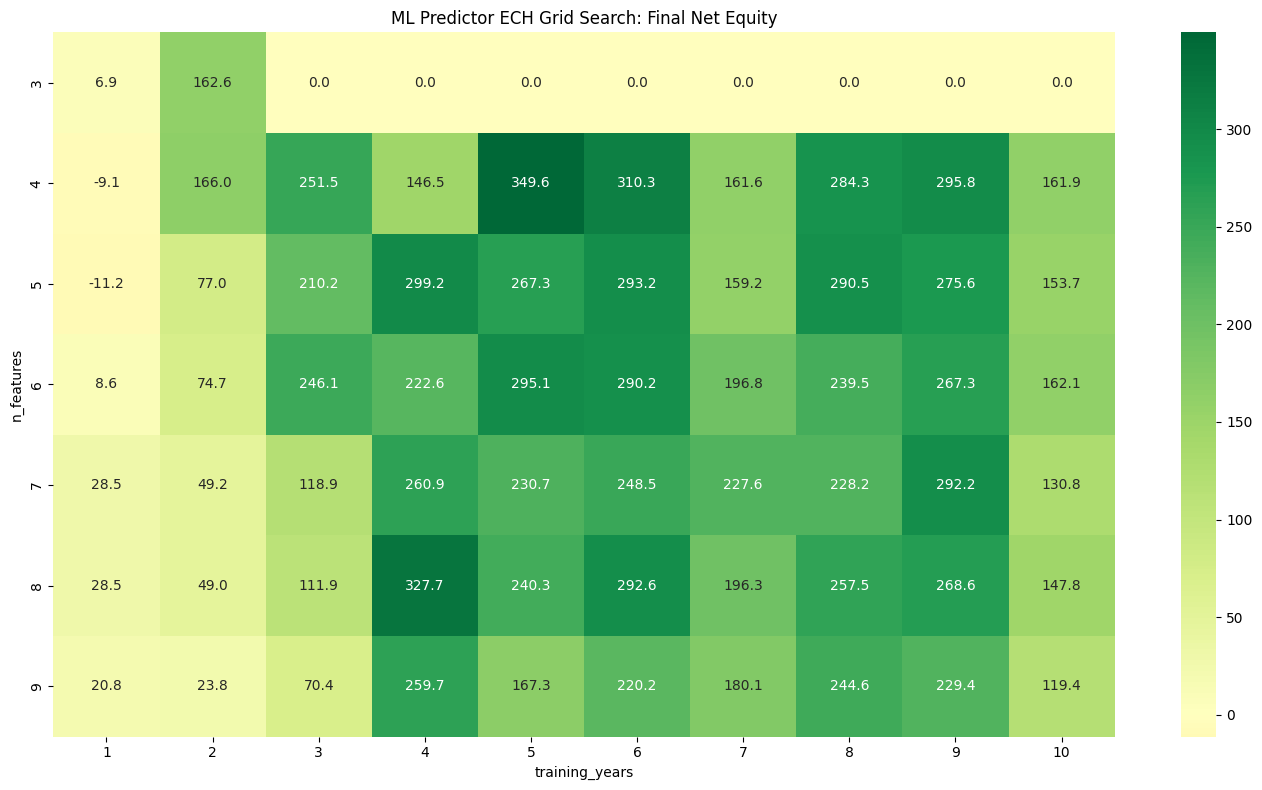

In [4]:
symbol = "ECH"
training_years_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# training_years_list = [1]
n_features_list = [3, 4, 5, 6, 7, 8, 9]
# n_features_list = [3]

cases = [
    (n_features, training_years)
    for n_features in n_features_list
    for training_years in training_years_list
]

grid_records = Parallel(n_jobs=-1, backend="threading")(
    delayed(run_grid_case)(symbol=symbol, n_features=n_features, training_years=training_years, signal_threshold=0.002, start_date="2018-01-01", end_date="2019-01-01")
    for n_features, training_years in cases
)

grid_records = [record for record in grid_records if record is not None]

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="training_years", values="net_return_pct")

display(grid_df.sort_values(["n_features", "training_years"]).reset_index(drop=True))

plt.figure(figsize=(14, 8))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Final Net Equity")
plt.xlabel("training_years")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

,symbol,start_date,end_date,signal_threshold,n_features,position_size,training_years,max_iter,verbose,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2018-01-01,2019-01-01,0.002,3,1.0,1,5000,False,2.008428,3.752980,1.020084e+06,1.037530e+06
1,ECH,2018-01-01,2019-01-01,0.002,3,1.0,2,5000,False,215.052391,223.566789,3.150524e+06,3.235668e+06
2,ECH,2018-01-01,2019-01-01,0.002,3,1.0,3,5000,False,147.496475,153.376567,2.474965e+06,2.533766e+06
3,ECH,2018-01-01,2019-01-01,0.002,3,1.0,4,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06
4,ECH,2018-01-01,2019-01-01,0.002,3,1.0,5,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,ECH,2018-01-01,2019-01-01,0.002,9,1.0,6,5000,False,234.497263,243.271777,3.344973e+06,3.432718e+06
66,ECH,2018-01-01,2019-01-01,0.002,9,1.0,7,5000,False,207.440424,216.614865,3.074404e+06,3.166149e+06
67,ECH,2018-01-01,2019-01-01,0.002,9,1.0,8,5000,False,218.471463,227.330925,3.184715e+06,3.273309e+06
68,ECH,2018-01-01,2019-01-01,0.002,9,1.0,9,5000,False,248.097709,257.430969,3.480977e+06,3.574310e+06


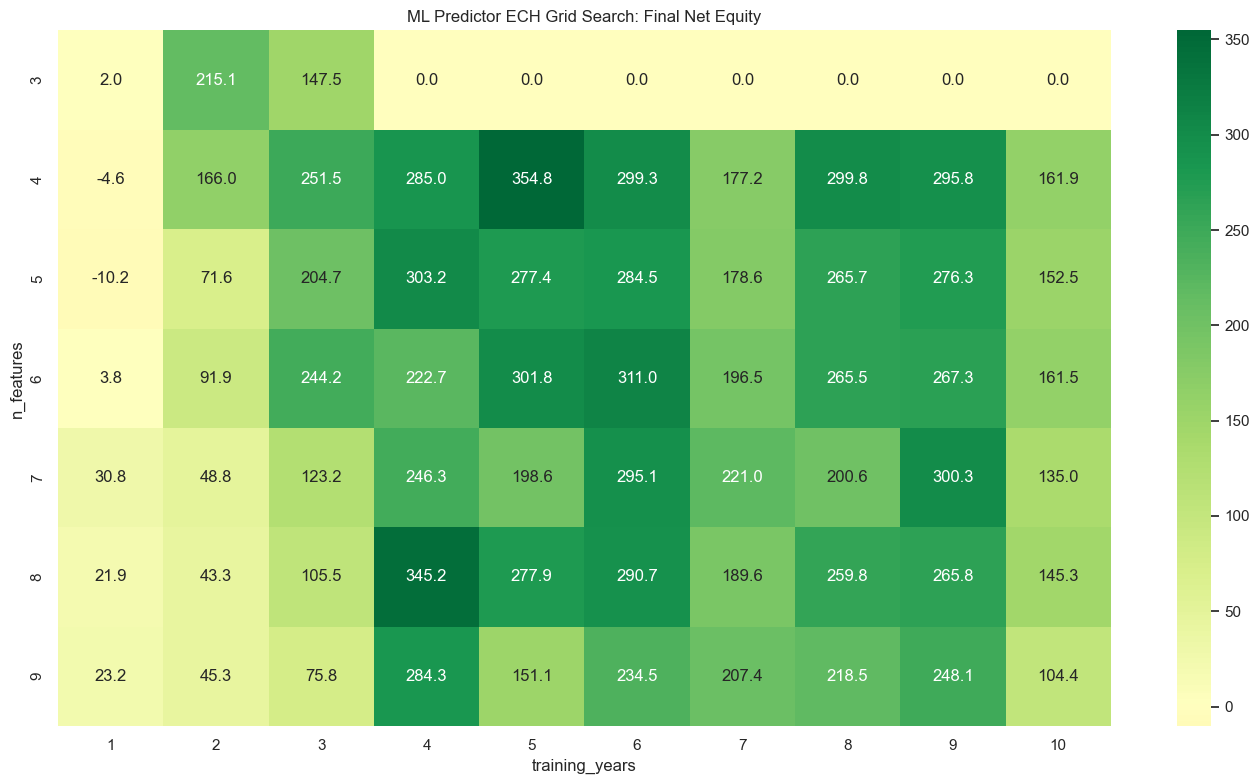

In [10]:
symbol = "ECH"
training_years_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# training_years_list = [1]
n_features_list = [3, 4, 5, 6, 7, 8, 9]
# n_features_list = [3]

cases = [
    (n_features, training_years)
    for n_features in n_features_list
    for training_years in training_years_list
]

grid_records = Parallel(n_jobs=-1, backend="threading")(
    delayed(run_grid_case)(symbol=symbol, n_features=n_features, training_years=training_years, signal_threshold=0.002, start_date="2018-01-01", end_date="2019-01-01")
    for n_features, training_years in cases
)

grid_records = [record for record in grid_records if record is not None]

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="training_years", values="net_return_pct")

display(grid_df.sort_values(["n_features", "training_years"]).reset_index(drop=True))

plt.figure(figsize=(14, 8))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Final Net Equity")
plt.xlabel("training_years")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

,symbol,start_date,end_date,signal_threshold,n_features,position_size,training_years,max_iter,verbose,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2018-01-01,2019-01-01,0.002,3,1.0,1,5000,False,2.008428,3.752980,1.020084e+06,1.037530e+06
1,ECH,2018-01-01,2019-01-01,0.002,3,1.0,2,5000,False,215.052391,223.566789,3.150524e+06,3.235668e+06
2,ECH,2018-01-01,2019-01-01,0.002,3,1.0,3,5000,False,147.496475,153.376567,2.474965e+06,2.533766e+06
3,ECH,2018-01-01,2019-01-01,0.002,3,1.0,4,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06
4,ECH,2018-01-01,2019-01-01,0.002,3,1.0,5,5000,False,0.000000,0.000000,1.000000e+06,1.000000e+06


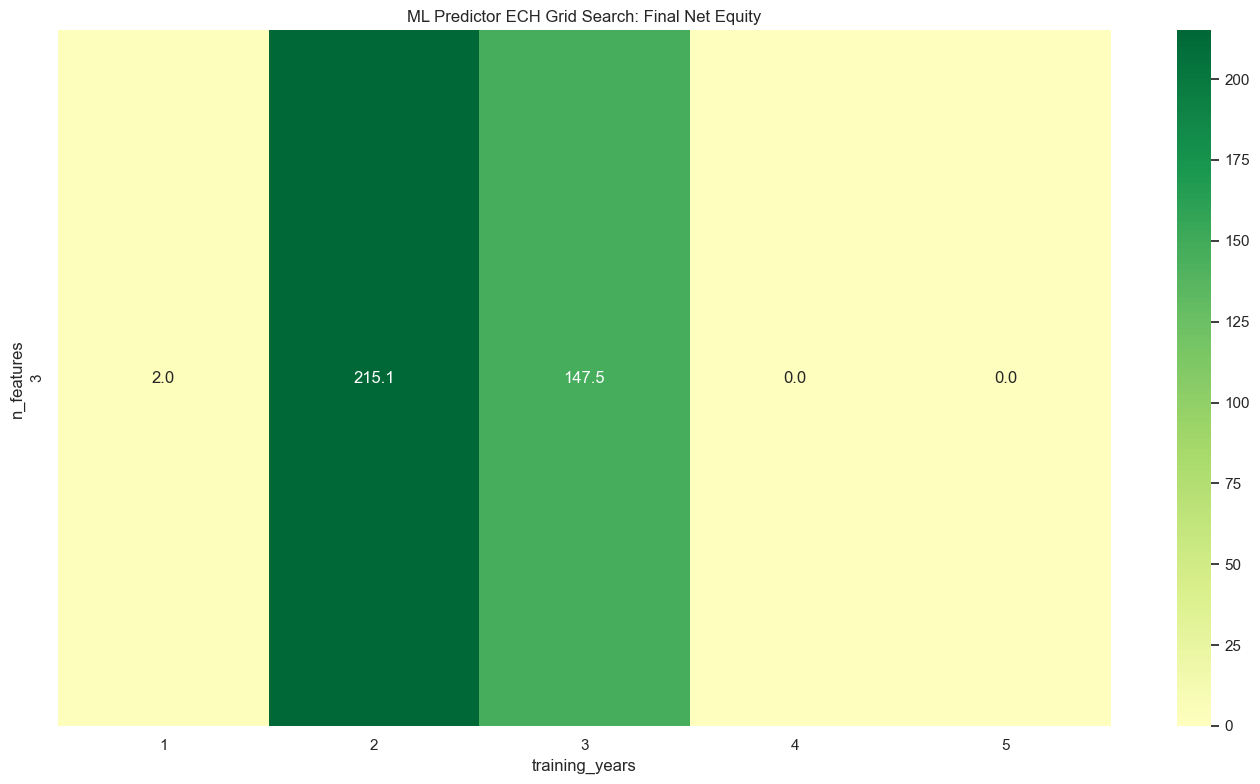

In [11]:
symbol = "ECH"
training_years_list = [1, 2, 3, 4, 5]
# training_years_list = [1]
n_features_list = [3]
# n_features_list = [3]

cases = [
    (n_features, training_years)
    for n_features in n_features_list
    for training_years in training_years_list
]

grid_records = Parallel(n_jobs=-1, backend="threading")(
    delayed(run_grid_case)(symbol=symbol, n_features=n_features, training_years=training_years, signal_threshold=0.002, start_date="2018-01-01", end_date="2019-01-01")
    for n_features, training_years in cases
)

grid_records = [record for record in grid_records if record is not None]

grid_df = pd.DataFrame(grid_records)
grid_pivot = grid_df.pivot(index="n_features", columns="training_years", values="net_return_pct")

display(grid_df.sort_values(["n_features", "training_years"]).reset_index(drop=True))

plt.figure(figsize=(14, 8))
sns.heatmap(grid_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title(f"ML Predictor {symbol} Grid Search: Final Net Equity")
plt.xlabel("training_years")
plt.ylabel("n_features")
plt.tight_layout()
plt.show()

I don't think the paralleled grid search is working properly. Let's test to see the runs individually and compare the resulst to the grid search.

-----------------      "ECH"   n_fetures = 3   signal_threshold=0.002      -----------------


TRAINING_YEARS = 1
🧠 Predicting 2018-12-31 |  251/251 |  last: 0.23s |  elapsed: 1m 24.4s251 |  last: 0.20s |  elapsed: 30.0s 102/251 |  last: 0.20s |  elapsed: 40.8s
✅ Prediction complete. Took 1m 24.6s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return: 8.29%
   Net Strategy Return: 6.86% (EW Benchmark: -20.45%)
   Max Drawdown:        -10.88%
   Win Rate (Bars):     51.8%
   Total Fees Paid:     $14,301.80
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


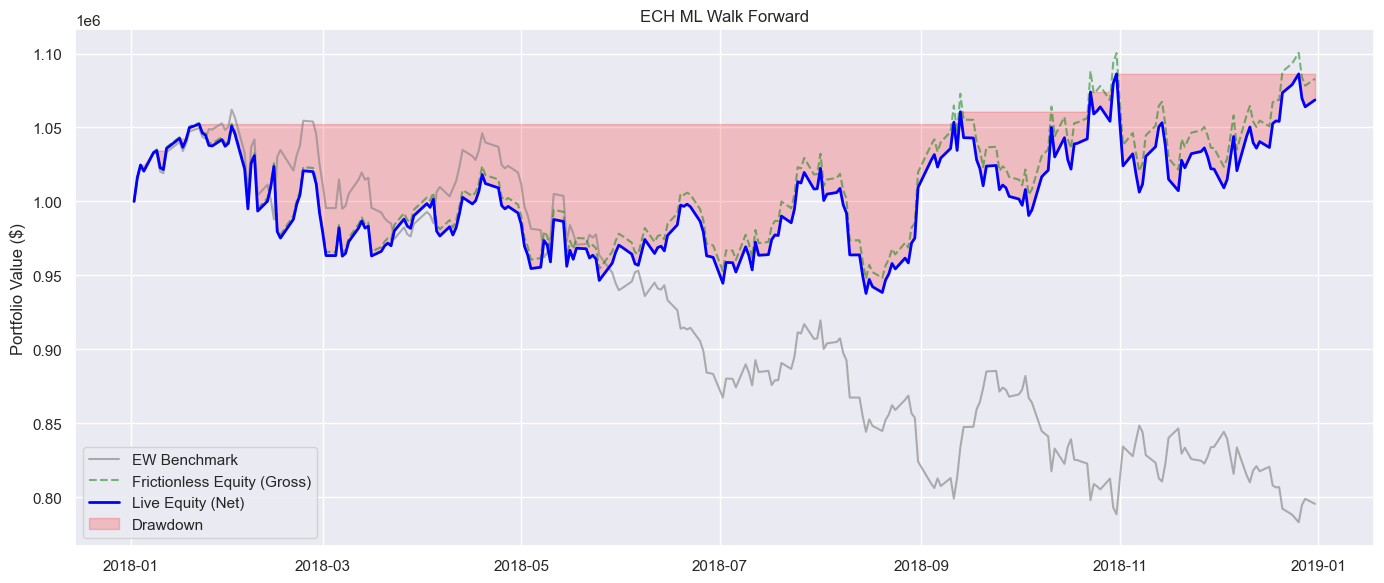


TRAINING_YEARS = 2
🧠 Predicting 2018-12-31 |  251/251 |  last: 0.45s |  elapsed: 1m 2.2s/251 |  last: 0.20s |  elapsed: 16.6s 96/251 |  last: 0.20s |  elapsed: 19.3s 124/251 |  last: 0.21s |  elapsed: 24.6s 126/251 |  last: 0.20s |  elapsed: 25.0s 159/251 |  last: 0.20s |  elapsed: 32.1s
✅ Prediction complete. Took 1m 2.7s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return: 223.57%
   Net Strategy Return: 215.05% (EW Benchmark: -20.45%)
   Max Drawdown:        -4.43%
   Win Rate (Bars):     65.7%
   Total Fees Paid:     $85,143.80
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


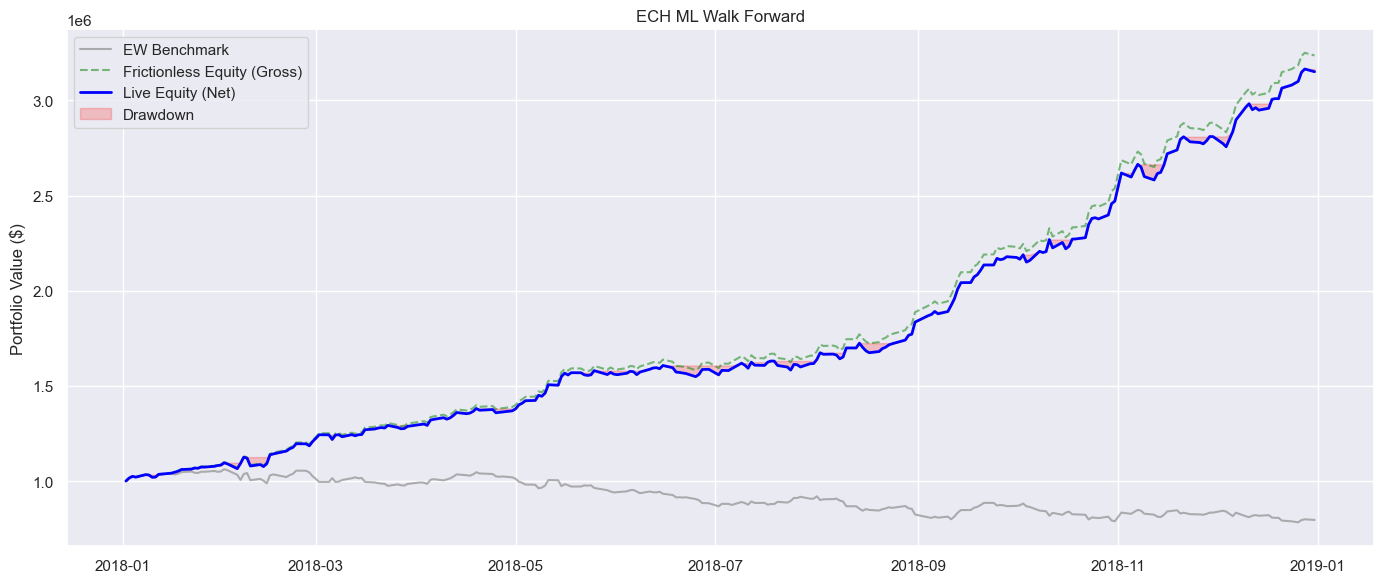


TRAINING_YEARS = 3
🧠 Predicting 2018-12-31 |  251/251 |  last: 0.33s |  elapsed: 57.3s5/251 |  last: 0.20s |  elapsed: 5.9s 79/251 |  last: 0.20s |  elapsed: 18.0s 147/251 |  last: 0.20s |  elapsed: 33.3s 219/251 |  last: 0.20s |  elapsed: 50.4s 221/251 |  last: 0.20s |  elapsed: 50.9s
✅ Prediction complete. Took 57.7s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return: 270.08%
   Net Strategy Return: 260.18% (EW Benchmark: -20.45%)
   Max Drawdown:        -2.92%
   Win Rate (Bars):     67.3%
   Total Fees Paid:     $99,058.33
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


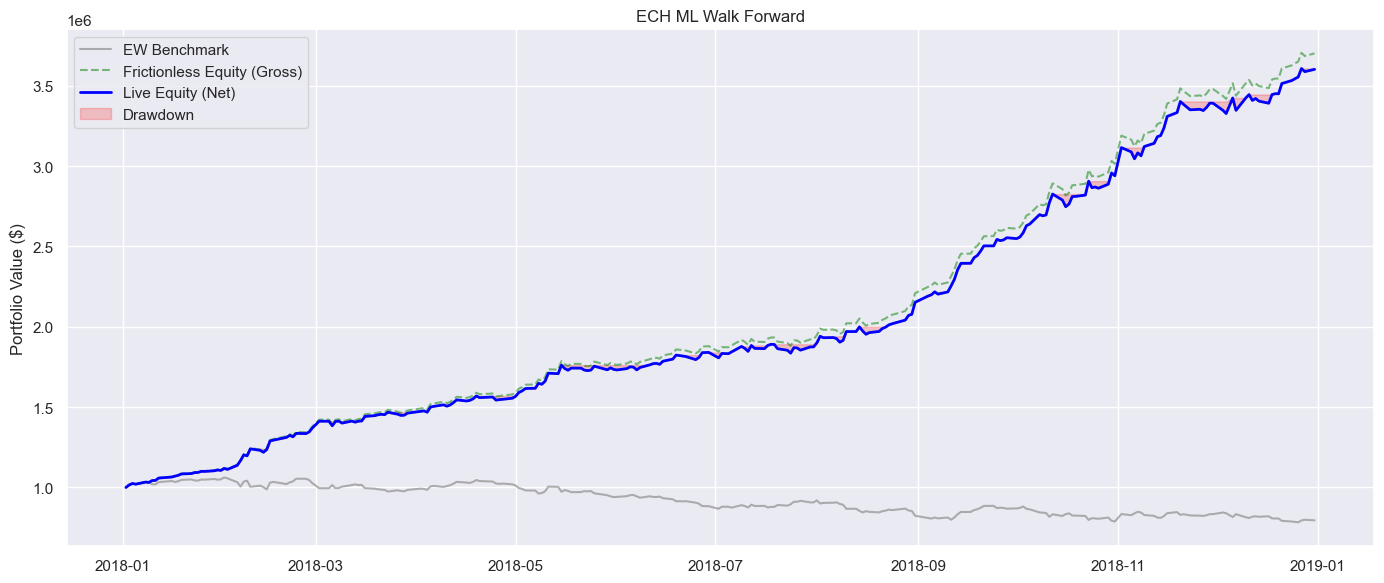


TRAINING_YEARS = 4
🧠 Predicting 2018-12-31 |  251/251 |  last: 0.23s |  elapsed: 1m 11.2s0/251 |  last: 0.21s |  elapsed: 34.2s
✅ Prediction complete. Took 1m 11.6s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return: 259.65%
   Net Strategy Return: 249.31% (EW Benchmark: -20.45%)
   Max Drawdown:        -7.24%
   Win Rate (Bars):     66.5%
   Total Fees Paid:     $103,367.44
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


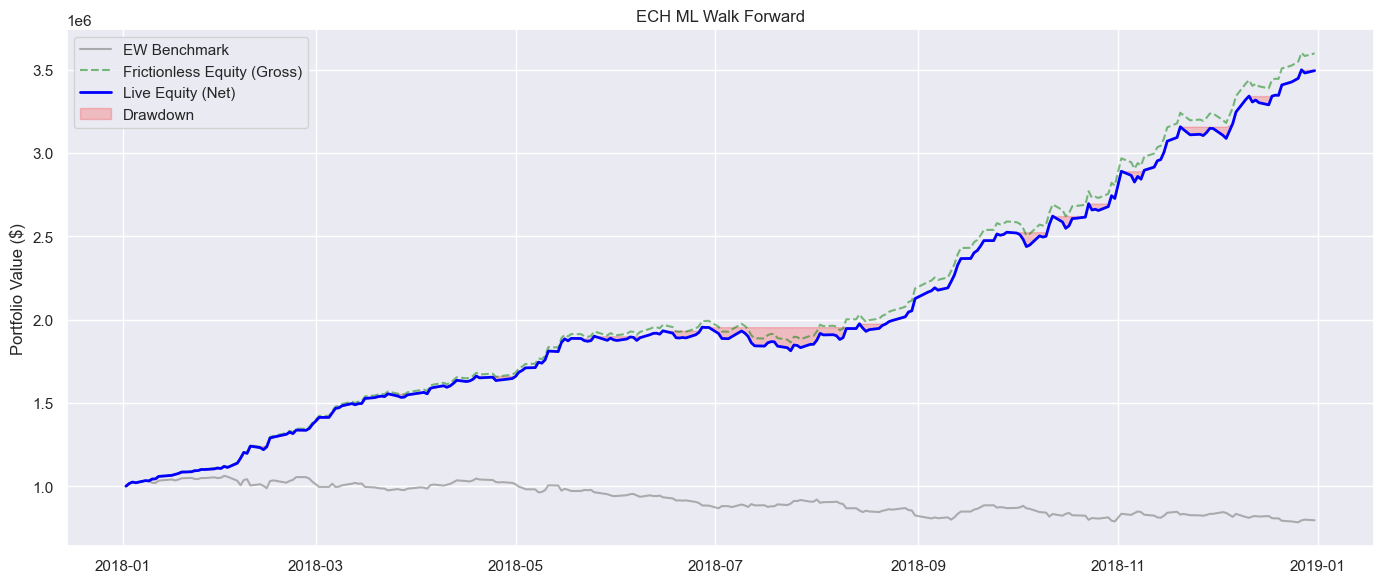


TRAINING_YEARS = 5
🧠 Predicting 2018-12-31 |  251/251 |  last: 0.39s |  elapsed: 1m 39.4s
✅ Prediction complete. Took 1m 39.8s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return: 378.56%
   Net Strategy Return: 366.60% (EW Benchmark: -20.45%)
   Max Drawdown:        -2.91%
   Win Rate (Bars):     72.5%
   Total Fees Paid:     $119,621.78
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


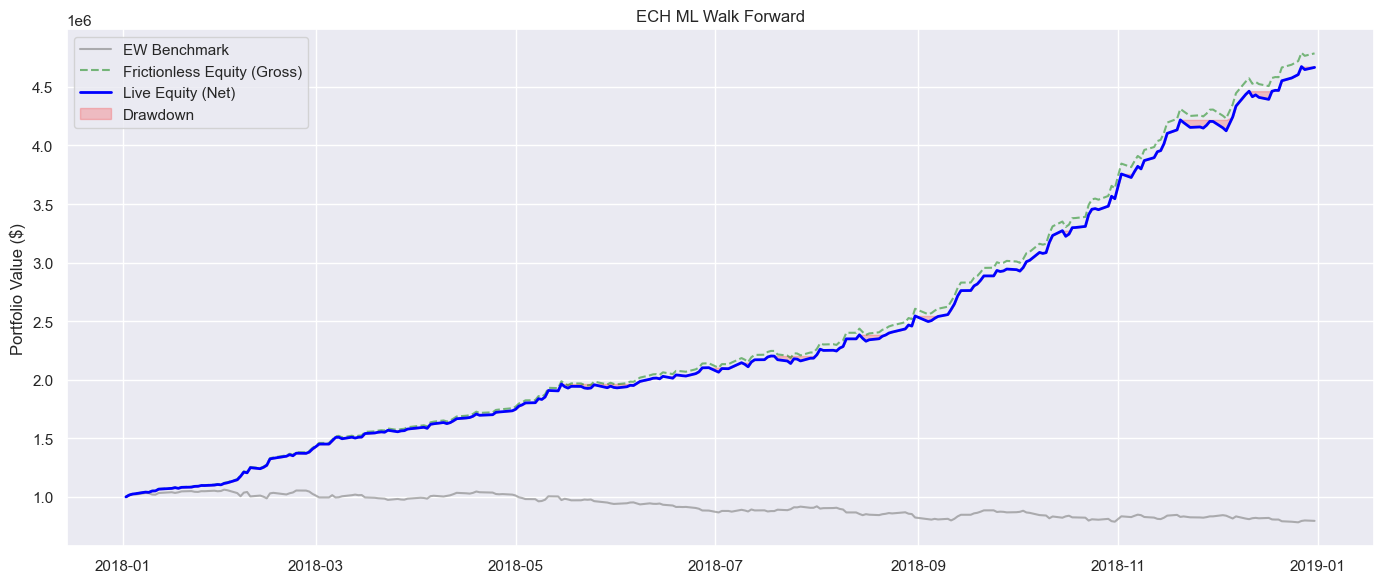

In [7]:
print('-----------------      "ECH"   n_fetures = 3   signal_threshold=0.002      -----------------')

# print("training_years=3".upper)
# run_single_case("ECH", n_features=3, signal_threshold=0.002, training_years=3)

for ty in [1, 2, 3, 4, 5]:
    print(f"\ntraining_years = {ty}".upper())
    run_single_case("ECH", n_features=3, signal_threshold=0.002, training_years=ty)


Seems like something isn't working properly with the parallelisation. Running the grid search with `n_features=3` for different values of `training_years` did not give the same result as running them as single runs. This needs better understanding and fixing.

#### ––––––––––     Test crypto     ––––––––––

🧠 Predicting 2025-12-31 |  365/365 |  last: 0.40s |  elapsed: 6m 2.8ss
✅ Prediction complete. Took 6m 3.5s


📊 --- QUICK PORTFOLIO RESULTS: BTC-USD ML Walk Forward ---
   Frictionless Return: -97.87%
   Net Strategy Return: -98.54% (EW Benchmark: -5.35%)
   Max Drawdown:        -98.54%
   Win Rate (Bars):     25.2%
   Total Fees Paid:     $6,720.36
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/BTC-USD_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


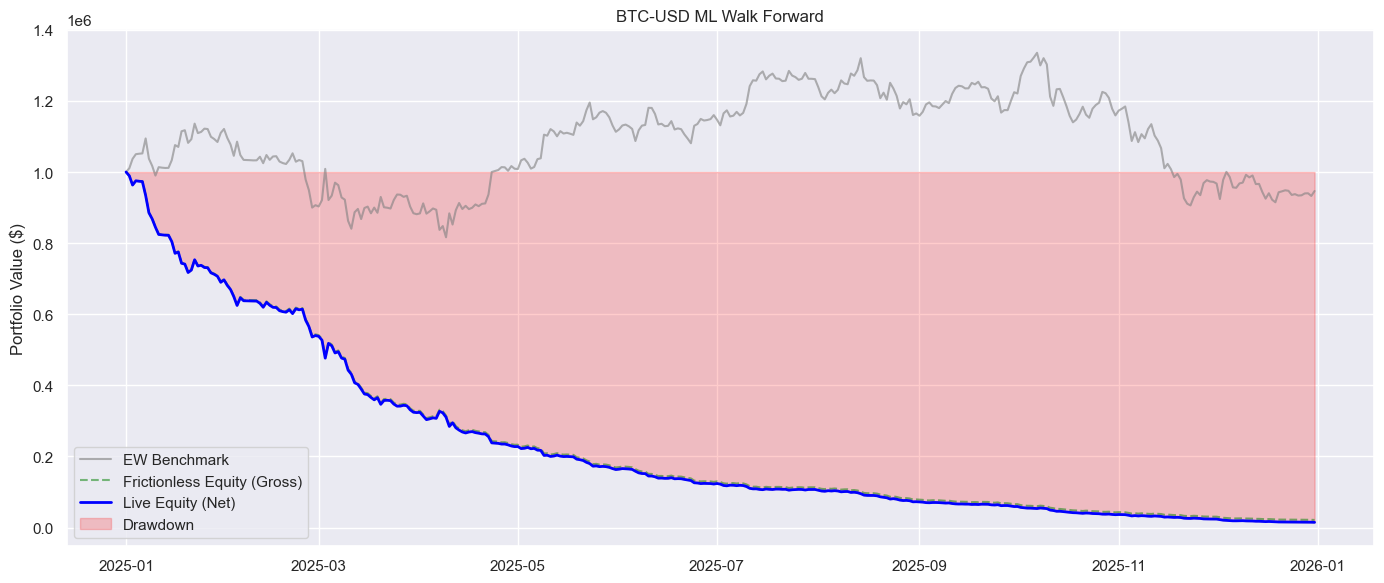

In [9]:
run_single_case("BTC-USD", start_date="2025-01-01", end_date="2026-01-01", n_features=10, signal_threshold=0.002, training_years=5)
